This is the main data analysis notebook of our work. In the following, the abbreviation OG means orbit graph.

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from data_analysis_functions import *
from qudit_lc import *
import os
import pandas as pd
from scipy.stats import skew, kurtosis
from matplotlib.ticker import MaxNLocator



Import all the extracted datasets found. The dataset is planar and will not be checked because the answer is False for every case. 

In [3]:
# Chromatic number of OG 
with open("og_data_final/join_og_chromatic_numbers.txt", "r") as f:
    data_og_chrom_number = eval(f.read())
data_og_chrom_number = np.array(data_og_chrom_number)

# Is OG planar: Bool. Will not be used.
with open("og_data_final/join_og_is_planar.txt", "r") as f:
    data_og_is_planar = eval(f.read())

data_og_is_planar = np.array(data_og_is_planar)
    
# Number of loops of OG 
with open("og_data_final/join_og_number_of_loops.txt", "r") as f:
    data_og_number_of_loops = eval(f.read())

data_og_number_of_loops = np.array(data_og_number_of_loops)

# Min Chromatic Number in OG 
with open("og_data_final/join_og_minimum_chromatic_number_in_OG.txt", "r") as f:
    data_og_minimum_chromatic_number_in_OG = eval(f.read())

data_og_minimum_chromatic_number_in_OG = np.array(data_og_minimum_chromatic_number_in_OG)

# Density of OG 
with open("og_data_final/join_og_density.txt", "r") as f:
    data_og_density = eval(f.read())

data_og_density = np.array(data_og_density)

# ASPL of OG 
data_og_aspl = np.loadtxt('og_data_final/join_final_aspl_large_run.txt')

# Diameter of OG 
with open("og_data_final/mc_1000_og_diameters_n7.txt", "r") as f:
    data_og_diameter = eval(f.read())
    
data_og_diameter = np.array(data_og_diameter)
    

# Min of the max degree for multigraphs in OG
with open("og_data_final/join_min_of_max_degree_in_OG.txt", "r") as f:
    data_min_of_max_degree_in_OG = eval(f.read())
    
data_min_of_max_degree_in_OG = np.array(data_min_of_max_degree_in_OG)


# Max degree of OG
with open("og_data_final/join_og_max_degree.txt", "r") as f:
    data_max_degree_of_OG = eval(f.read())
    
data_max_degree_of_OG = np.array(data_max_degree_of_OG)


#Schmidt Measure
with open("og_data_final/join_sm_in_og.txt", "r") as f:
    data_SM = eval(f.read())

# Function to flatten and handle sublists by replacing [a, b] with their mean. This function also exists in the corresponding module
def flatten_and_modify(nested_list):
    """
    Explained in sm_final_data.py
    """
    flat_list = []
    for item in nested_list:
        if isinstance(item, list):  # If item is a list, check if it needs modification
            if len(item) == 2:  # If the list has exactly two elements, take their mean
                flat_list.append(np.mean(item))
            else:
                flat_list.extend(flatten_and_modify(item))  # Recursively flatten and add to the list
        else:
            flat_list.append(item)  # If it's not a list, just append it
    return flat_list

# Flatten the data with modifications
flattened_data_SM = flatten_and_modify(data_SM)

# Convert to a NumPy array
data_final_SM = np.array(flattened_data_SM)

help_array = ["data_og_chrom_number", "data_og_number_of_loops","data_og_minimum_chromatic_number_in_OG","data_og_density", "data_og_aspl", "data_og_diameter", "data_min_of_max_degree_in_OG","data_max_degree_of_OG","data_final_SM"]


**Statistical Properties of each individual observable**

***Skewness*** is a measure of symmetry, or more precisely, the lack of symmetry. A distribution, or data set, is symmetric if it looks the same to the left and right of the center point.

***Kurtosis*** is a measure of whether the data are heavy-tailed or light-tailed relative to a normal distribution. That is, data sets with high kurtosis tend to have heavy tails, or outliers. Data sets with low kurtosis tend to have light tails, or lack of outliers. A uniform distribution would be the extreme case.

In [4]:
def stat_properties(input_np_file, name_of_dataset, print_resutls=True):
    """
    Calculates and optionally prints the statistical properties of a dataset.

    This function computes common statistical measures such as mean, 
    standard deviation, variance, median, mode, range, interquartile range 
    (IQR), skewness, and kurtosis for a given input dataset. The results 
    can be printed to the console if specified.

    Parameters:
    input_np_file (numpy.ndarray): A NumPy array containing the dataset to analyze.
    name_of_dataset (str): A name or label for the dataset, used for printing results.
    print_resutls (bool, optional): If True, prints the statistical results to the console. Default is True.

    Returns:
    tuple: A tuple containing the following statistical properties:
        - mean (float): The mean of the dataset.
        - std_dev (float): The standard deviation of the dataset.
        - variance (float): The variance of the dataset.
        - median (float): The median of the dataset.
        - mode (float): The mode of the dataset.
        - range_value (float): The range (difference between max and min values).
        - iqr (float): The interquartile range (difference between 75th and 25th percentiles).
        - skewness (float): The skewness of the dataset.
        - kurt (float): The kurtosis of the dataset.

    Example:
    mean, std_dev, variance, median, mode, range_value, iqr, skewness, kurt = stat_properties(data, 'MyDataset')
    """
    mean = np.mean(input_np_file)
    std_dev = np.std(input_np_file)
    variance = np.var(input_np_file)
    median = np.median(input_np_file)
    mode = pd.Series(input_np_file).mode()[0]  # First mode (in case there are multiple)
    range_value = np.max(input_np_file) - np.min(input_np_file)
    iqr = np.percentile(input_np_file, 75) - np.percentile(input_np_file, 25)
    skewness = skew(input_np_file)
    kurt = kurtosis(input_np_file)
    
    if print_resutls:
        print(f"Statistical Properties of {str(name_of_dataset)}:\n")
        print(f"Mean:          {mean:.5f}")
        print(f"Standard Deviation: {std_dev:.5f}")
        print(f"Variance:      {variance:.5f}")
        print(f"Median:        {median:.5f}")
        print(f"Mode:          {mode:.5f}")
        print(f"Range:         {range_value:.5f}")
        print(f"Interquartile Range (IQR): {iqr:.5f}")
        print(f"Skewness:      {skewness:.5f}")
        print(f"Kurtosis:      {kurt:.5f}")
    return mean, std_dev, variance, median, mode, range_value, iqr, skewness, kurt

# Friedman-Diaconis rule to compute the optimal number of bins
def friedman_diaconis_bins(data):
    """
    Computes the number of bins for a histogram using the Friedman-Diaconis rule.

    The Friedman-Diaconis rule calculates an optimal number of bins for a 
    histogram based on the interquartile range (IQR) of the data and the size 
    of the dataset. It is designed to minimize the bias-variance trade-off in 
    histogram binning.

    Parameters:
    data (numpy.ndarray or list): The dataset for which to calculate the optimal 
                                   number of bins.

    Returns:
    int: The optimal number of bins according to the Friedman-Diaconis rule.

    Example:
    num_bins = friedman_diaconis_bins(data)
    """
    # Calculate the interquartile range (IQR)
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    
    # Calculate the number of bins
    bin_width = 2 * iqr / len(data)**(1/3)
    num_bins = int(np.ceil((data.max() - data.min()) / bin_width))
    
    return num_bins


def plot_single_data_metrics(input_np_file, choose_header_name):
    """
    Plots a histogram and a boxplot for a given dataset.

    This function creates a figure with two subplots:
    1. A histogram using the Friedman-Diaconis rule to determine the optimal number of bins.
    2. A boxplot for visualizing the distribution of the data.

    Parameters:
    input_np_file (numpy.ndarray or list): The dataset to be visualized.
    choose_header_name (str): The name of the dataset or variable to be used in the plot title.

    Returns:
    matplotlib.figure.Figure: The figure object containing the histogram and boxplot.

    Example:
    fig = plot_single_data_metrics(data, 'MyDataset')
    """
    # Create the figure and axes
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Calculate number of bins for histogram using Friedman-Diaconis rule
    num_bins = friedman_diaconis_bins(input_np_file)

    # Histogram
    axes[0].hist(input_np_file, bins=num_bins, color='skyblue', edgecolor='black')
    axes[0].set_title("Histogram")
    axes[0].set_xlabel("Value")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True)
    axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))  # Set y-axis to integer

    # Boxplot
    axes[1].boxplot(input_np_file, patch_artist=True, boxprops=dict(facecolor='lightgreen', edgecolor='black'))
    axes[1].set_title("Boxplot")
    axes[1].set_ylabel("Value")
    axes[1].grid(True)
    axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))  # Set y-axis to integer

    # Add title for the entire figure
    fig.suptitle(f"Histrogram and Box Plot of {str(choose_header_name)}", fontsize=16)

    return fig  # Return the figure object, no plt.show() here


def plot_obs_vs_orbits(input_np_file, label_of_plot, x_label, y_label, title_of_plot):
    """
    Plots observed data against orbital indices, with additional statistical annotations.

    This function creates a plot of the input data with the following features:
    1. A line plot of the data.
    2. A horizontal line representing the mean of the data.
    3. A shaded region representing ±1 standard deviation from the mean.

    Parameters:
    input_np_file (numpy.ndarray or list): The dataset to be plotted.
    label_of_plot (str): The label for the plot line.
    x_label (str): The label for the x-axis.
    y_label (str): The label for the y-axis.
    title_of_plot (str): The title for the plot.

    Returns:
    matplotlib.figure.Figure: The figure object containing the plot with statistical annotations.

    Example:
    fig = plot_obs_vs_orbits(data, 'Data Label', 'Orbit Index', 'Value', 'Observation vs Orbit')
    """
    # Create the plot
    fig = plt.figure(figsize=(10, 6))
    plt.plot(input_np_file, 'o-', label=str(label_of_plot), color='blue')
    mean = np.mean(input_np_file)
    std = np.std(input_np_file)
    
    # Add mean line and ±1σ range
    plt.axhline(y=mean, color='black', linestyle='-', label=f'Mean: {mean:.2f}')
    plt.fill_between(np.arange(len(input_np_file)), mean - std, mean + std,
                     color='green', alpha=0.2, label=f'±1$\sigma$ ({std:.2f})')

    # Labels and title
    plt.xlabel(str(x_label))
    plt.ylabel(str(y_label))
    plt.title(str(title_of_plot))
    plt.legend()
    plt.grid(True)

    return fig  # Return the figure object, no plt.show() here



In the following, we are going to derive the important statistical properties of the observable dataset along with some relevant plots.

Statistical Properties of $E_S$:

Mean:          2.84466
Standard Deviation: 0.64998
Variance:      0.42247
Median:        3.00000
Mode:          3.00000
Range:         2.50000
Interquartile Range (IQR): 0.50000
Skewness:      -1.24049
Kurtosis:      0.94858


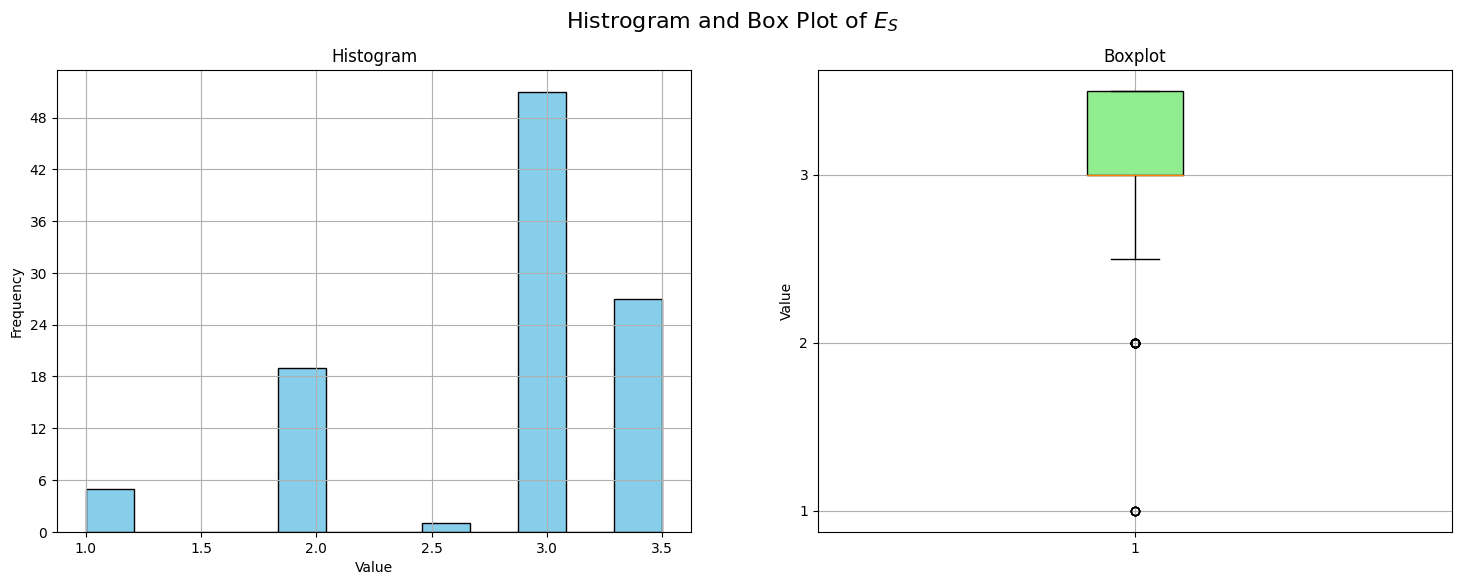

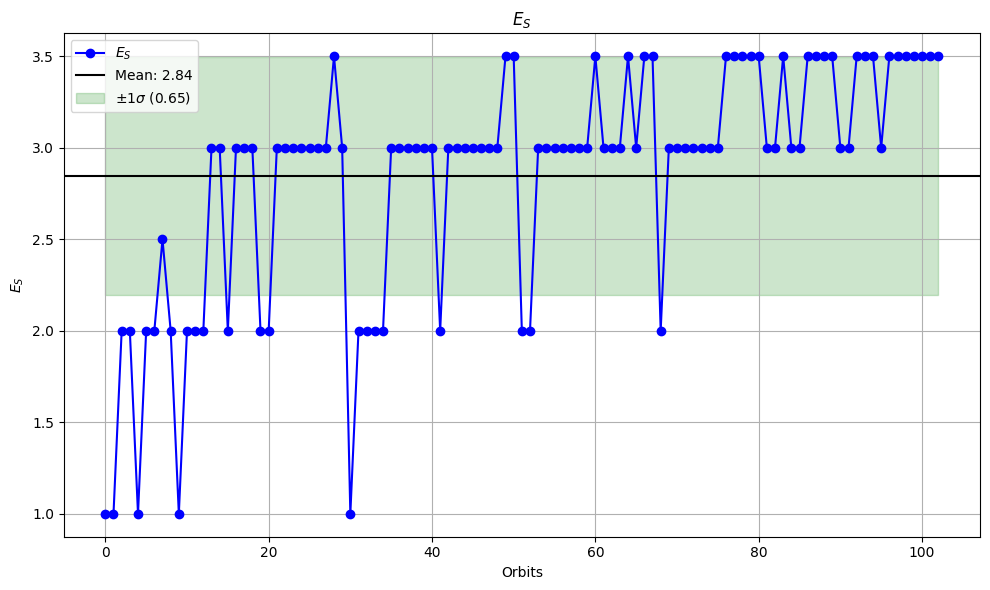

In [5]:
input_np_file = data_final_SM
stat_properties(input_np_file,"$E_S$")
fig1 = plot_single_data_metrics(input_np_file, "$E_S$")
fig2 = plot_obs_vs_orbits(input_np_file, "$E_S$", "Orbits", "$E_S$", "$E_S$")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of Minimum of the maximum degrees in OG:

Mean:          3.76699
Standard Deviation: 0.80295
Variance:      0.64474
Median:        4.00000
Mode:          4.00000
Range:         4.00000
Interquartile Range (IQR): 1.00000
Skewness:      0.55744
Kurtosis:      0.77824


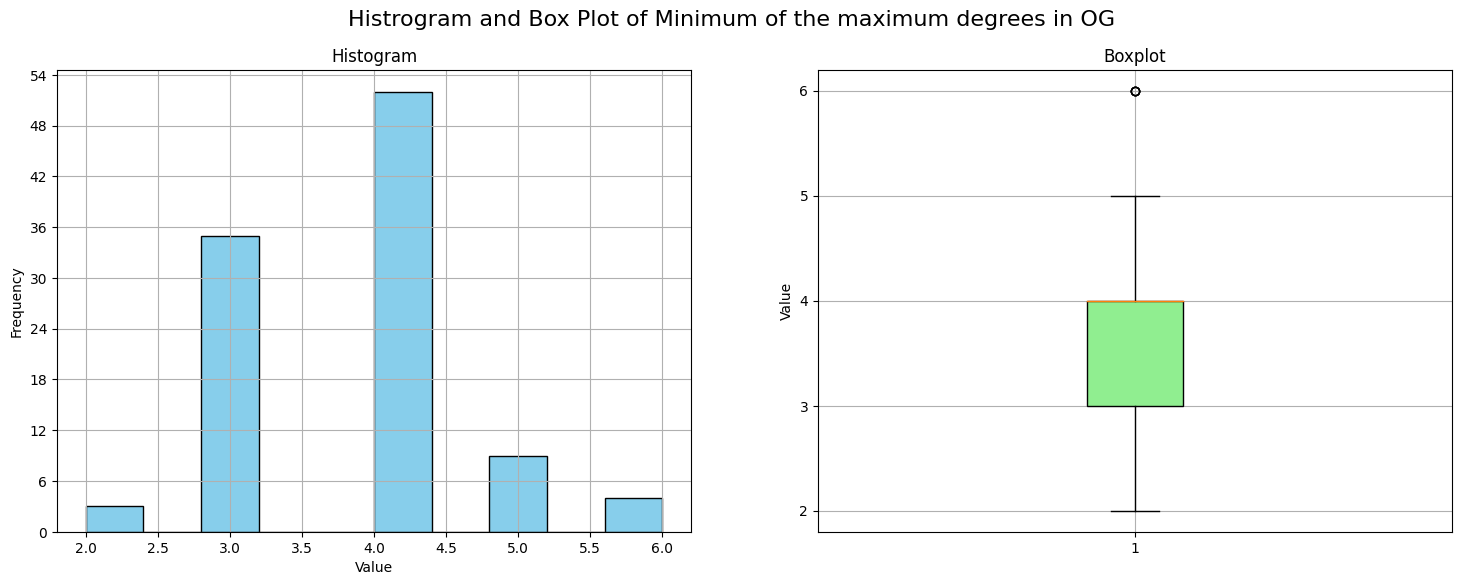

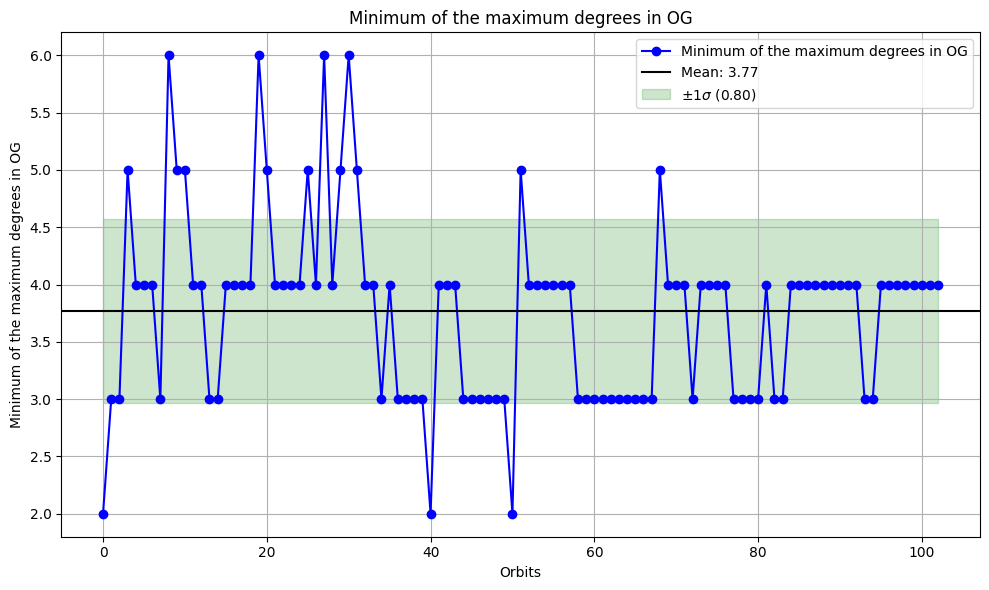

In [6]:
# Generate the plots without showing them
input_np_file = data_min_of_max_degree_in_OG
stat_properties(input_np_file,"Minimum of the maximum degrees in OG")
fig1 = plot_single_data_metrics(input_np_file, "Minimum of the maximum degrees in OG")
fig2 = plot_obs_vs_orbits(input_np_file, "Minimum of the maximum degrees in OG", "Orbits", "Minimum of the maximum degrees in OG", "Minimum of the maximum degrees in OG")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of Max degree of OG:

Mean:          17.96117
Standard Deviation: 4.20569
Variance:      17.68781
Median:        20.00000
Mode:          21.00000
Range:         17.00000
Interquartile Range (IQR): 4.00000
Skewness:      -1.66583
Kurtosis:      2.22953


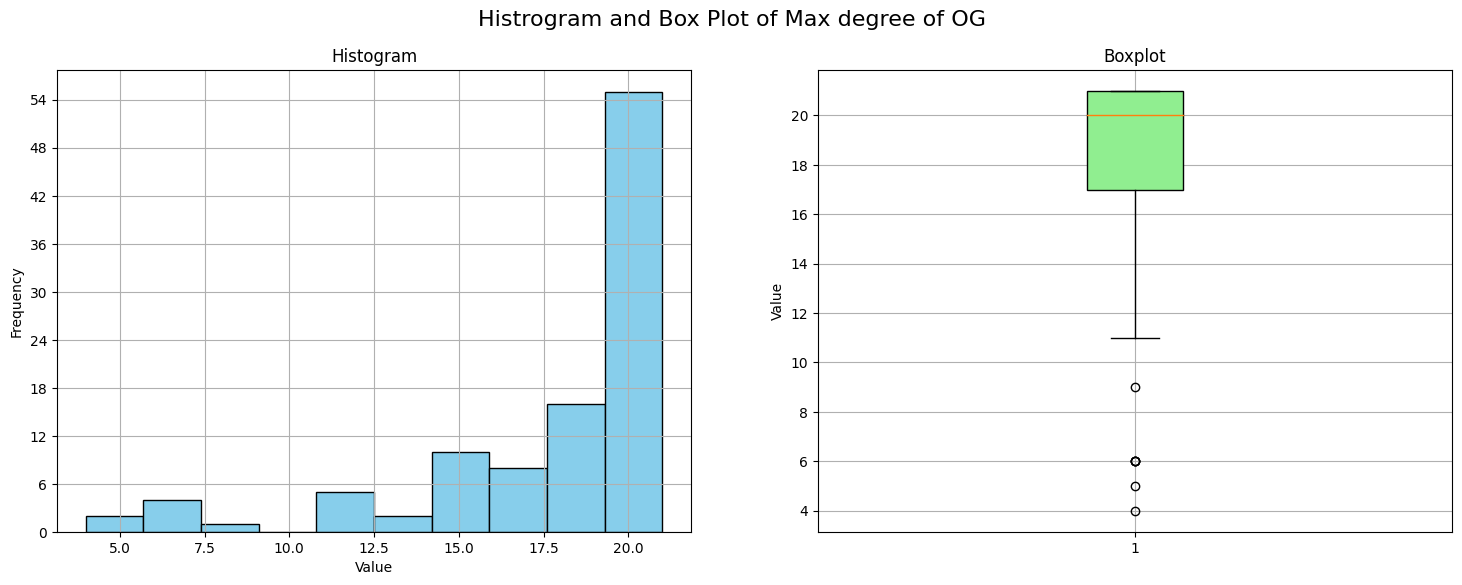

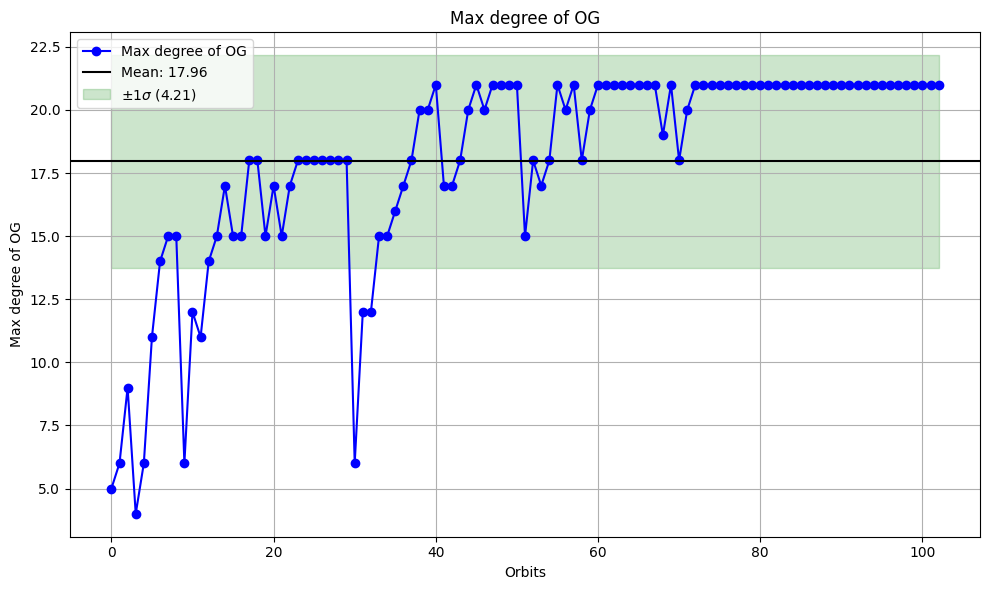

In [7]:
# Generate the plots without showing them
input_np_file = data_max_degree_of_OG
stat_properties(input_np_file,"Max degree of OG")
fig1 = plot_single_data_metrics(input_np_file, "Max degree of OG")
fig2 = plot_obs_vs_orbits(input_np_file, "Max degree of OG", "Orbits", "Max degree of OG", "Max degree of OG")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of OG Chromatic Number:

Mean:          9.11650
Standard Deviation: 2.45068
Variance:      6.00584
Median:        10.00000
Mode:          10.00000
Range:         9.00000
Interquartile Range (IQR): 3.00000
Skewness:      -0.89075
Kurtosis:      0.14245


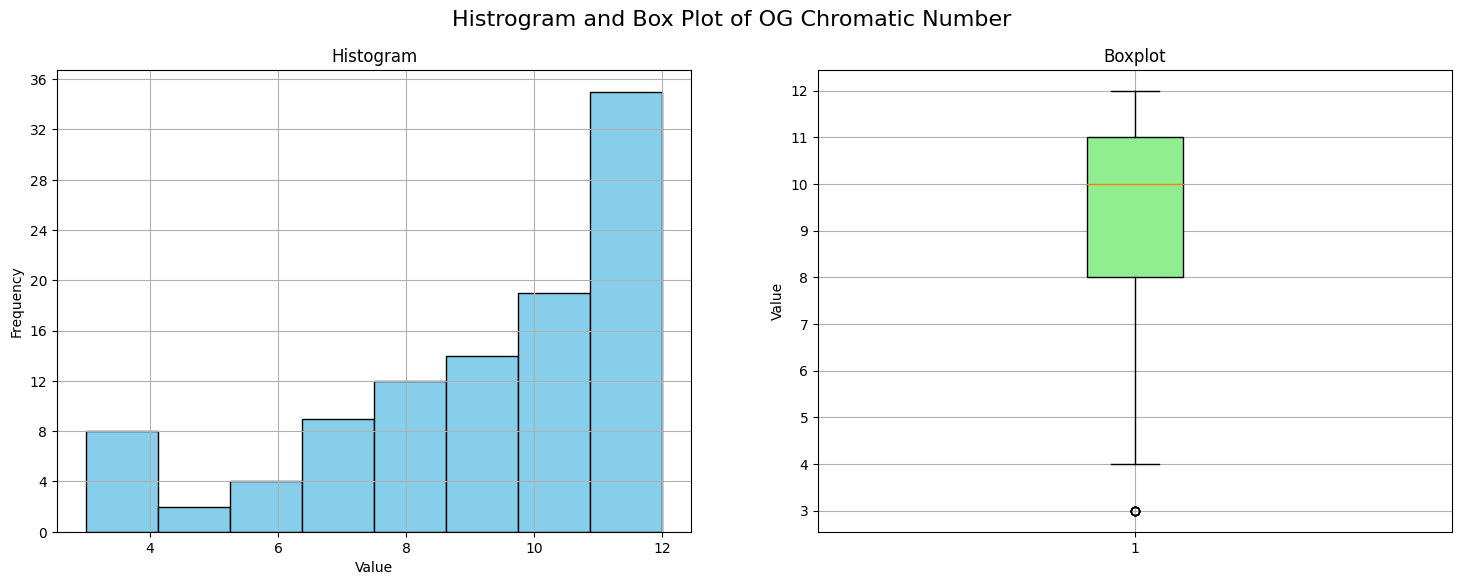

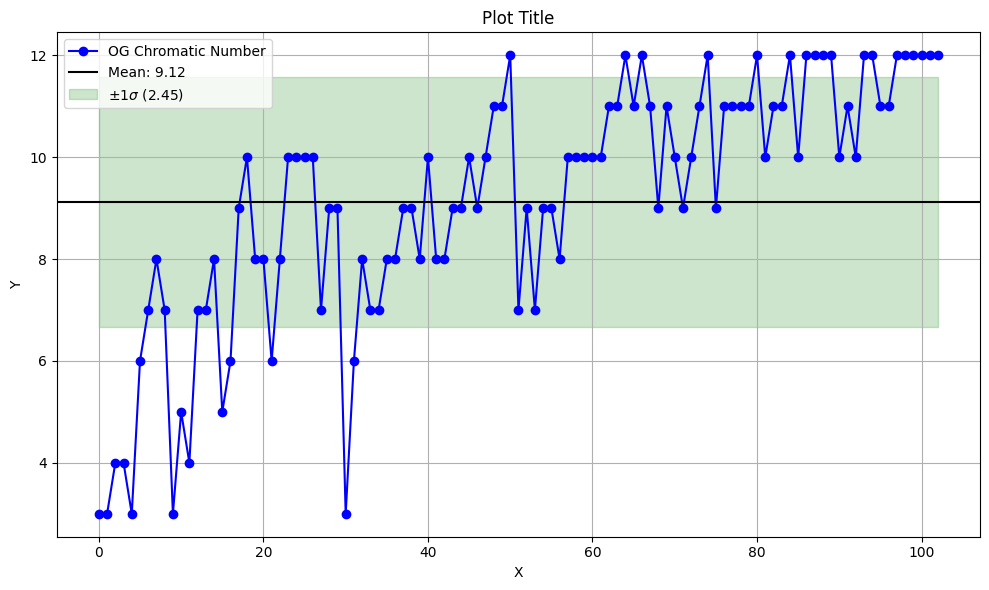

In [8]:
# Generate the plots without showing them
input_np_file = data_og_chrom_number
stat_properties(input_np_file,"OG Chromatic Number")
fig1 = plot_single_data_metrics(input_np_file, "OG Chromatic Number")
fig2 = plot_obs_vs_orbits(input_np_file, "OG Chromatic Number", "X", "Y", "Plot Title")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of OG ASPL:

Mean:          3.85249
Standard Deviation: 1.02645
Variance:      1.05361
Median:        4.07053
Mode:          2.83668
Range:         4.62281
Interquartile Range (IQR): 1.52861
Skewness:      -0.40401
Kurtosis:      -0.36653


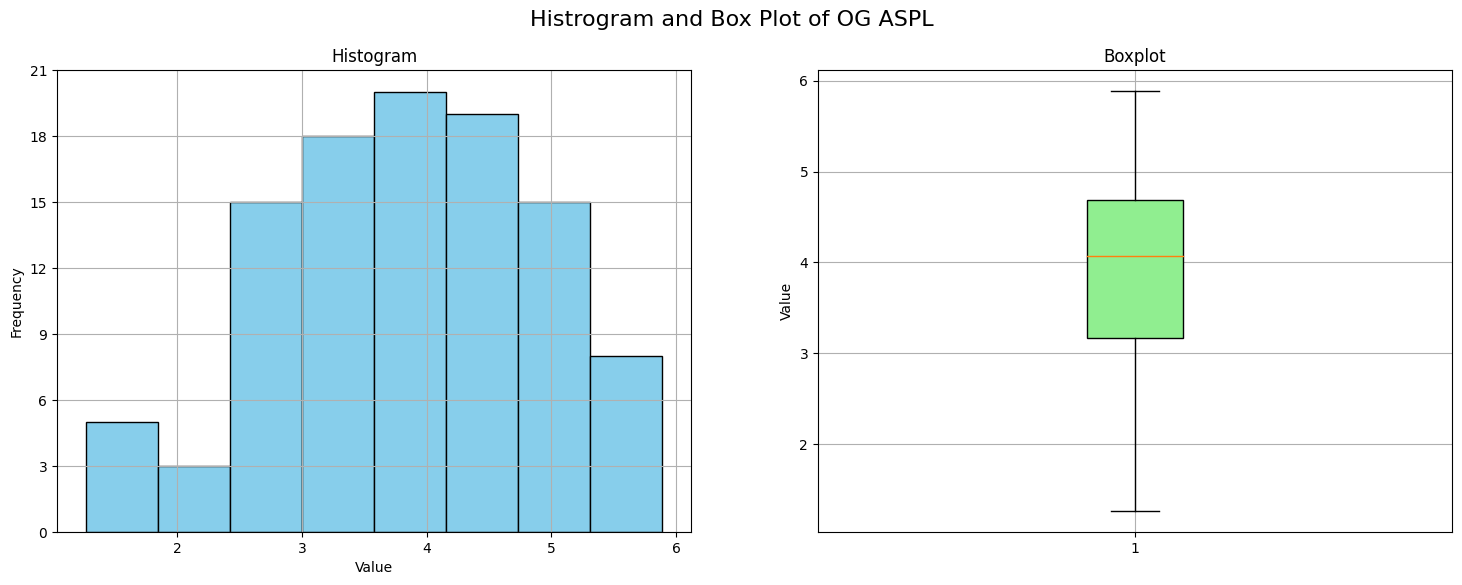

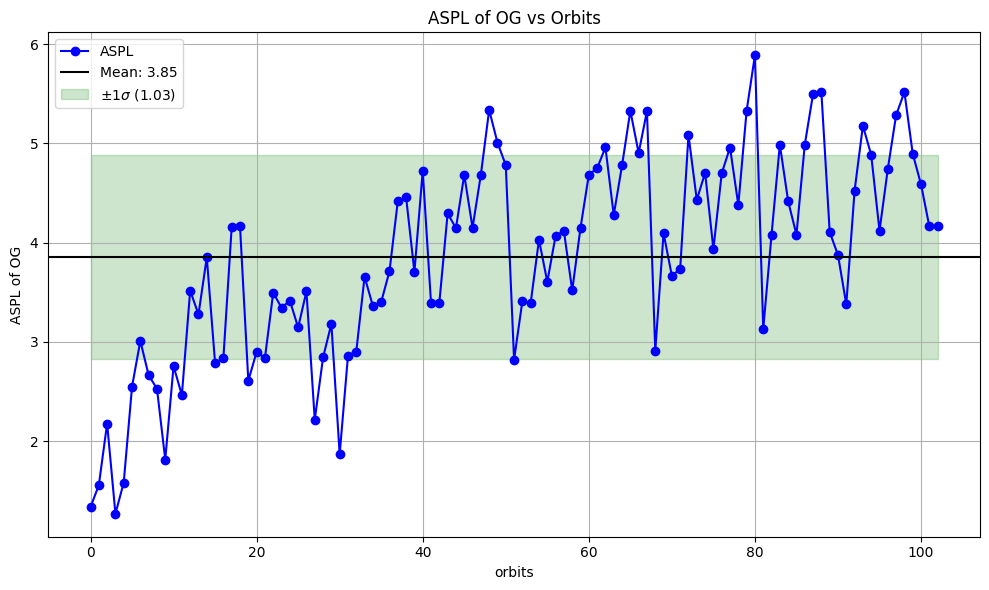

In [9]:
# Generate the plots without showing them
input_np_file = data_og_aspl
stat_properties(input_np_file,"OG ASPL")
fig1 = plot_single_data_metrics(input_np_file,"OG ASPL")
fig2 = plot_obs_vs_orbits(input_np_file,"ASPL", "orbits", "ASPL of OG","ASPL of OG vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of OG Number of Loops:

Mean:          2674.96117
Standard Deviation: 4912.77983
Variance:      24135405.61014
Median:        507.00000
Mode:          108.00000
Range:         22632.00000
Interquartile Range (IQR): 2245.00000
Skewness:      2.76741
Kurtosis:      7.46490


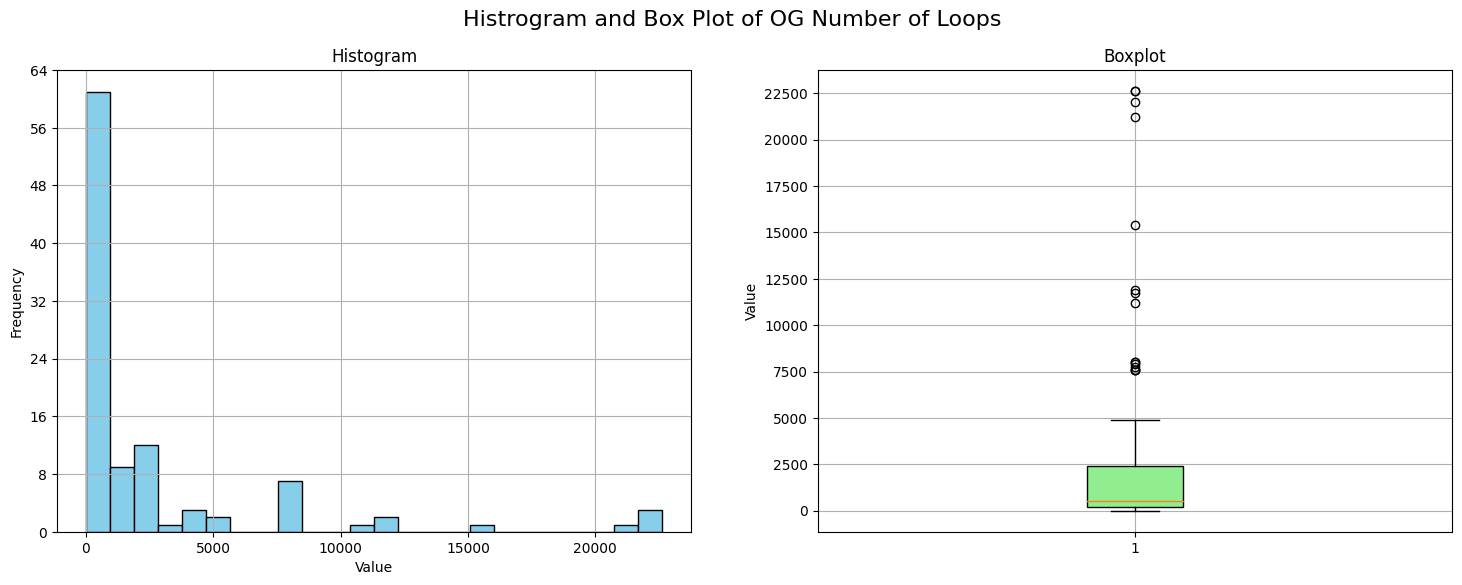

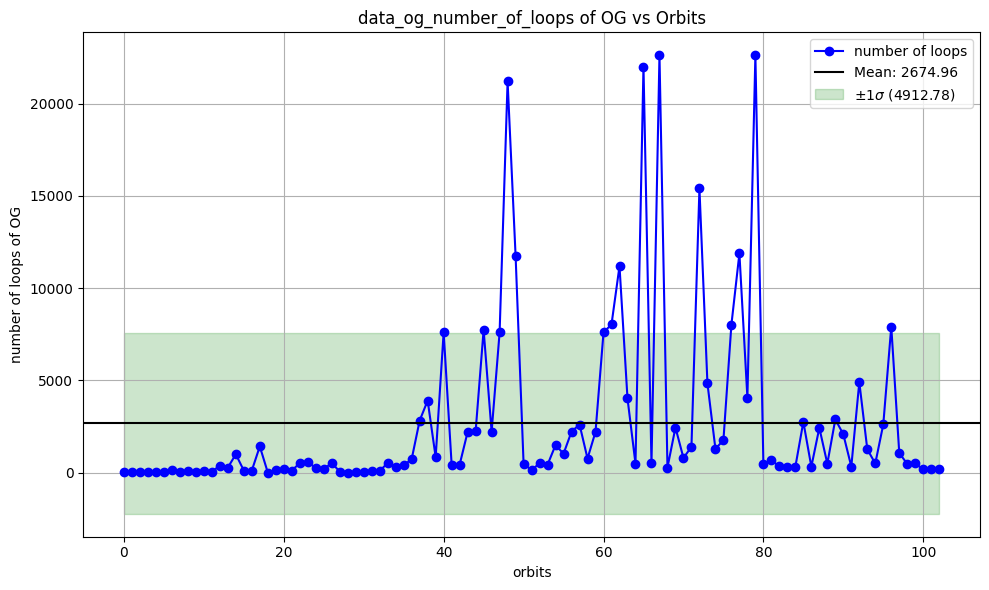

In [10]:
# Generate the plots without showing them
input_np_file = data_og_number_of_loops
stat_properties(input_np_file,"OG Number of Loops")
fig1 = plot_single_data_metrics(input_np_file,"OG Number of Loops")
fig2 = plot_obs_vs_orbits(input_np_file,"number of loops", "orbits", "number of loops of OG","data_og_number_of_loops of OG vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of $\chi_{s}$:

Mean:          2.39806
Standard Deviation: 0.48950
Variance:      0.23961
Median:        2.00000
Mode:          2.00000
Range:         1.00000
Interquartile Range (IQR): 1.00000
Skewness:      0.41652
Kurtosis:      -1.82651


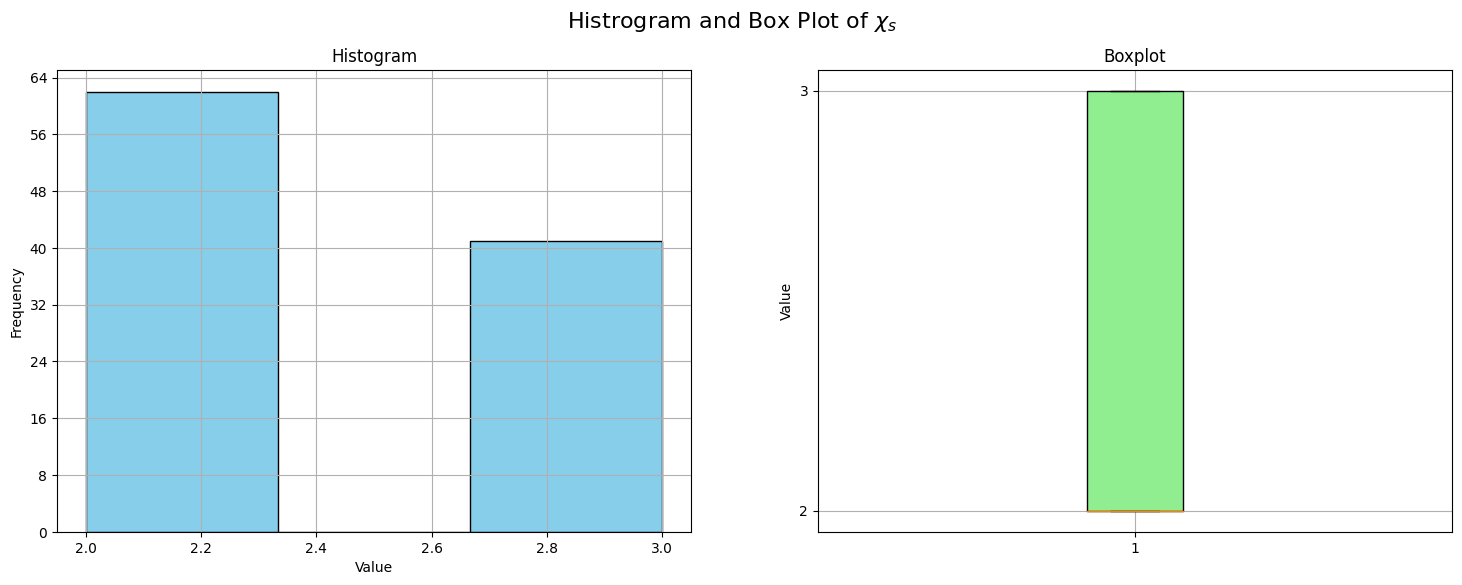

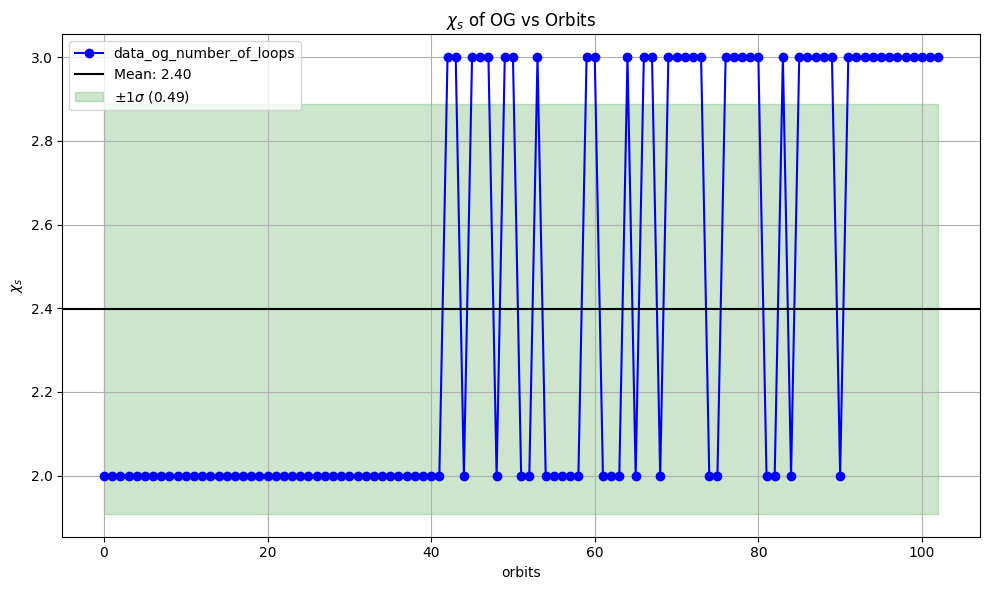

In [11]:
# Generate the plots without showing them
input_np_file = data_og_minimum_chromatic_number_in_OG
stat_properties(input_np_file,"$\chi_{s}$")
fig1 = plot_single_data_metrics(input_np_file,"$\chi_{s}$")
fig2 = plot_obs_vs_orbits(input_np_file,"data_og_number_of_loops", "orbits", "$\chi_{s}$","$\chi_{s}$ of OG vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready

Statistical Properties of $D_{OG}$:

Mean:          -5.19463
Standard Deviation: 2.25901
Variance:      5.10311
Median:        -5.30816
Mode:          -8.21349
Range:         9.81512
Interquartile Range (IQR): 3.07868
Skewness:      0.24328
Kurtosis:      -0.65402


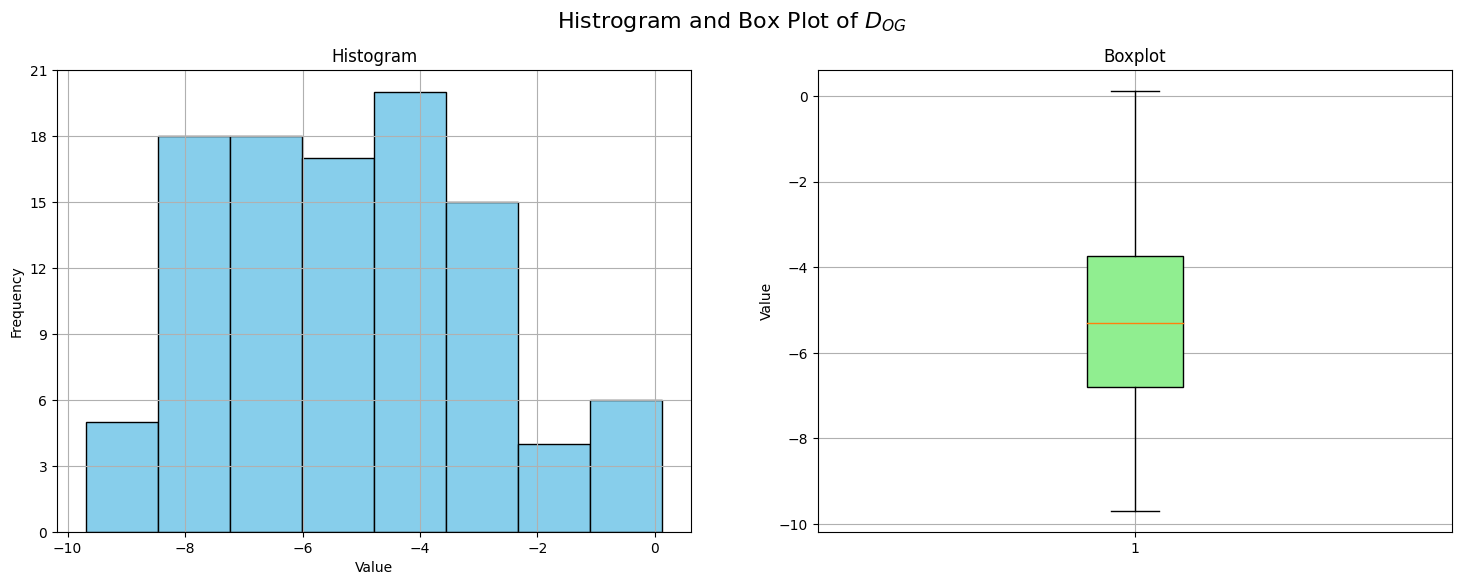

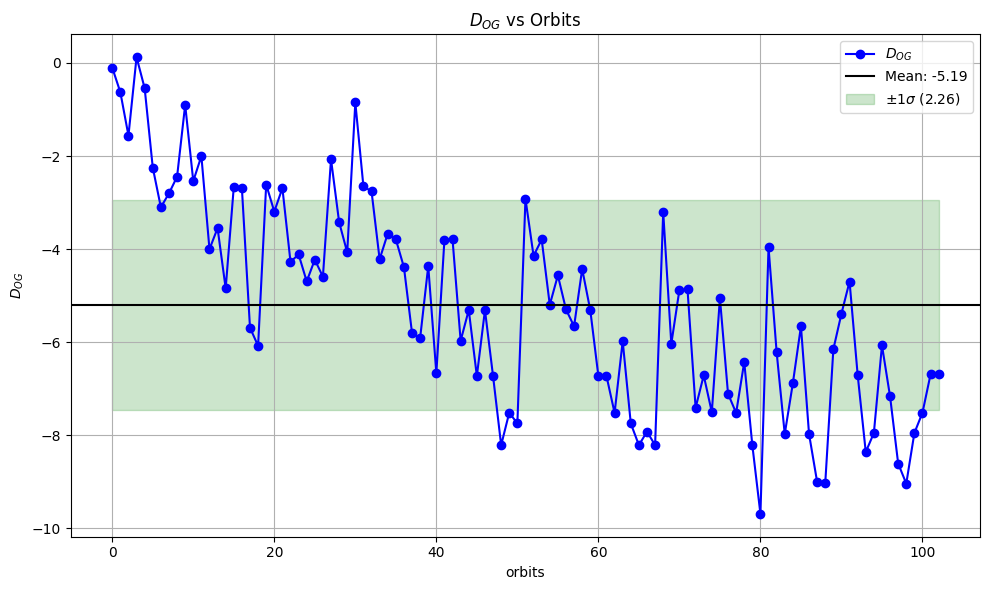

In [12]:
input_np_file = np.log(data_og_density)
stat_properties(input_np_file,"$D_{OG}$")
fig1 = plot_single_data_metrics(input_np_file,"$D_{OG}$")
fig2 = plot_obs_vs_orbits(input_np_file,"$D_{OG}$", "orbits", "$D_{OG}$","$D_{OG}$ vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready


Statistical Properties of Diameter:

Mean:          6.41748
Standard Deviation: 1.54872
Variance:      2.39853
Median:        7.00000
Mode:          7.00000
Range:         7.00000
Interquartile Range (IQR): 1.00000
Skewness:      -0.66884
Kurtosis:      0.50157


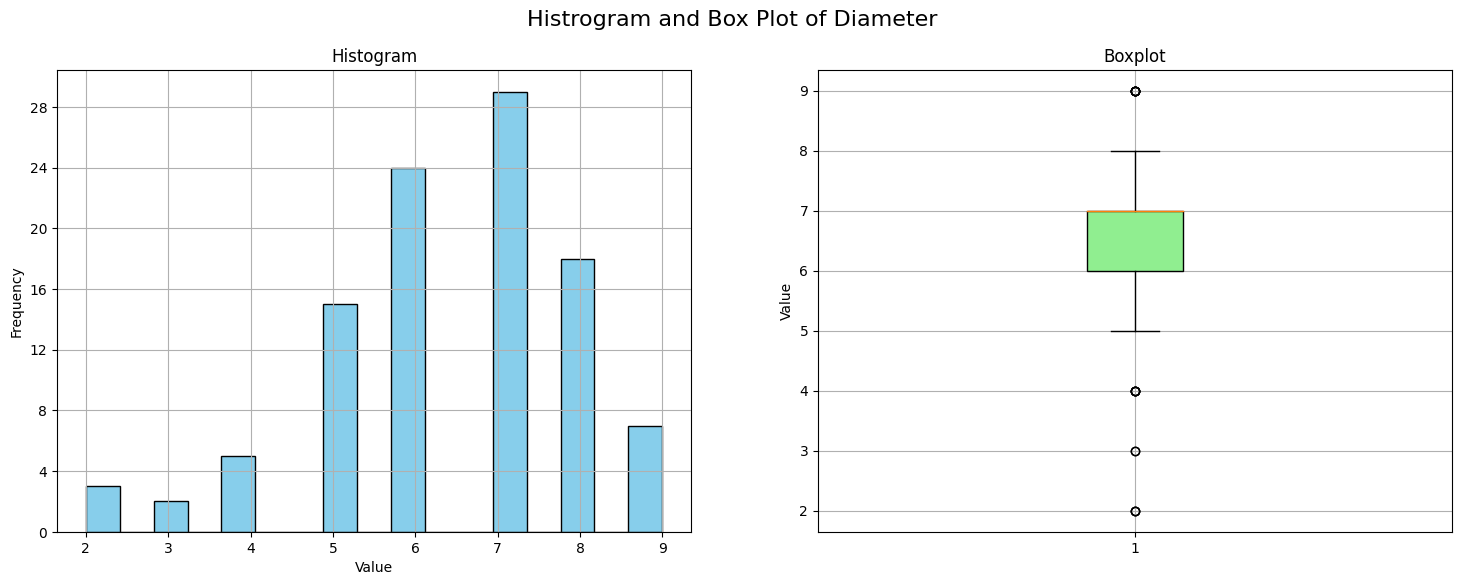

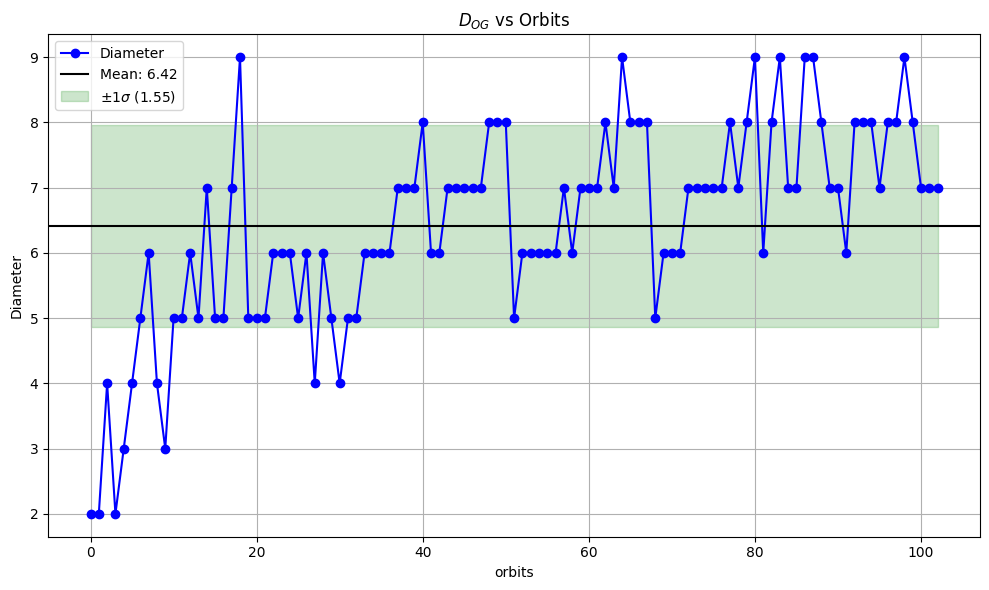

In [13]:
input_np_file = data_og_diameter
stat_properties(input_np_file,"Diameter")
fig1 = plot_single_data_metrics(input_np_file,"Diameter")
fig2 = plot_obs_vs_orbits(input_np_file,"Diameter", "orbits", "Diameter","$D_{OG}$ vs Orbits")

# Now display both figures at once
plt.tight_layout()
plt.show()  # Only call this once after all plots are ready


Now we have to build the correlation plots.

In [14]:
# Define a dictionary for the coefficients 
pearson_dictionary = dict()

In [15]:
from scipy.stats import pearsonr, spearmanr, kendalltau, zscore

correlation_dict = dict()

def plot_coef_and_find_pearson(x, y, x_label, y_label):
    """
    Computes and plots the correlation between two datasets, storing results in a global dictionary.

    This function performs the following tasks:
    1. Computes the Pearson and Kendall Tau correlation coefficients and their corresponding p-values between `x` and `y`.
    2. Stores these statistical results in a global dictionary `correlation_dict` using a key formatted as "x_label vs y_label".
    3. Prints the computed correlation coefficients and p-values.
    4. Creates and displays a scatter plot of `x` versus `y`.

    Parameters:
    x (array-like): The first set of observations (independent variable).
    y (array-like): The second set of observations (dependent variable).
    x_label (str): Label for the x-axis and part of the key in the correlation dictionary.
    y_label (str): Label for the y-axis and part of the key in the correlation dictionary.

    Returns:
    None

    Notes:
    - This function assumes the existence of a global variable `correlation_dict` (a dictionary) where results are stored.
    - Displays the scatter plot directly using `plt.show()`.

    Example:
    plot_coef_and_find_pearson(array1, array2, "Feature X", "Feature Y")
    """
    dict_name = f"{x_label} vs {y_label}"

    # Ensure the key exists in the dictionary
    if dict_name not in correlation_dict:
        correlation_dict[dict_name] = {}

    # Pearson correlation
    pearson_coef, pearson_pvalue = pearsonr(x, y)
    correlation_dict[dict_name]["pearson_coef"] = pearson_coef
    correlation_dict[dict_name]["pearson_pvalue"] = pearson_pvalue

    # Kendall Tau correlation
    kendall_coef, kendall_pvalue = kendalltau(x, y)
    correlation_dict[dict_name]["kendall_coef"] = kendall_coef
    correlation_dict[dict_name]["kendall_pvalue"] = kendall_pvalue

    # Print results
    print(f"Pearson correlation coefficient: {pearson_coef:.4f}")
    print(f"Pearson p-value: {pearson_pvalue:.4e}")
    print(f"Kendall Tau coefficient: {kendall_coef:.4f}")
    print(f"Kendall p-value: {kendall_pvalue:.4e}")

    # Scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, color='blue', alpha=0.9)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f"{x_label} vs {y_label}")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()


In the following, we are implementing every possible combination to get the correlation coefficients. We have to manually do it because in some cases logarithmic scale should be used.

Pearson correlation coefficient: 0.8555
Pearson p-value: 1.2358e-30
Kendall Tau coefficient: 0.7436
Kendall p-value: 2.9264e-20


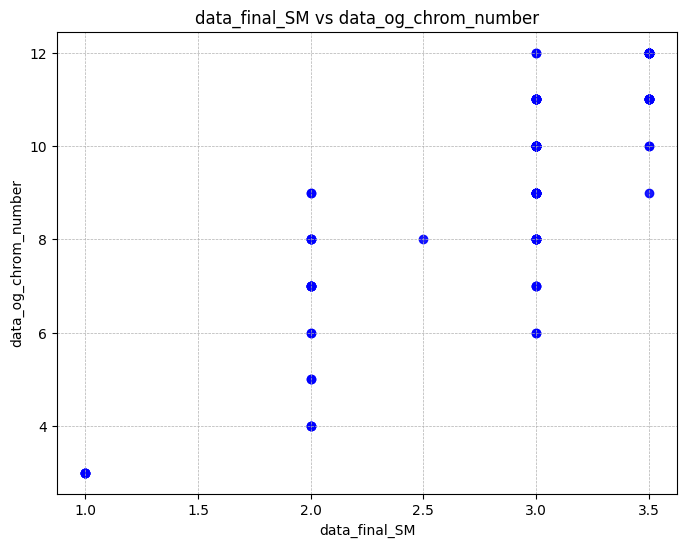

In [16]:
x = data_final_SM
x_label = "data_final_SM"

y = data_og_chrom_number
y_label = "data_og_chrom_number"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.5793
Pearson p-value: 1.4473e-10
Kendall Tau coefficient: 0.3893
Kendall p-value: 3.3074e-07


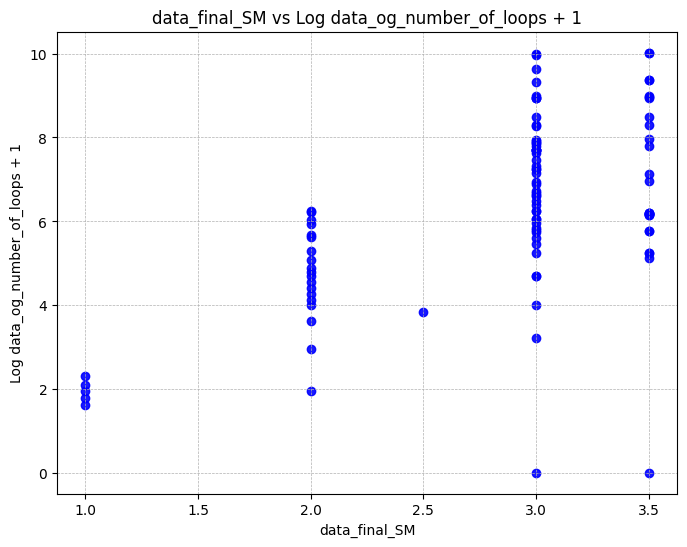

In [17]:
x = data_final_SM
x_label = "data_final_SM"

y = np.log(data_og_number_of_loops+1)
y_label = "Log data_og_number_of_loops + 1"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.5910
Pearson p-value: 4.9454e-11
Kendall Tau coefficient: 0.6575
Kendall p-value: 1.3172e-12


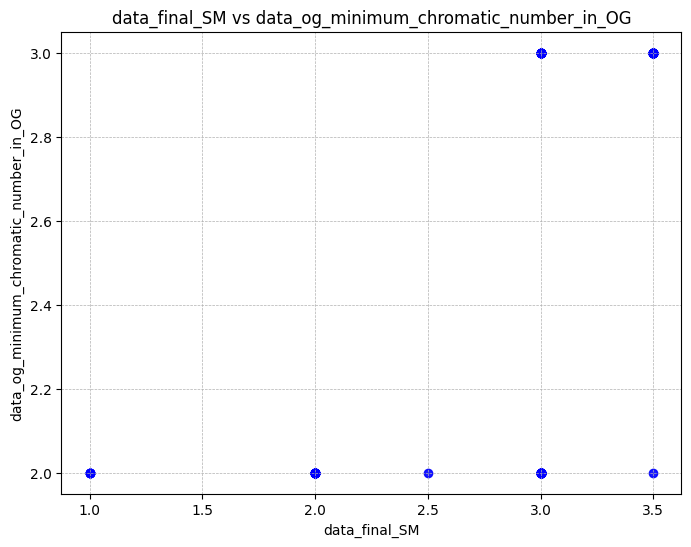

In [18]:
x = data_final_SM
x_label = "data_final_SM"

y = data_og_minimum_chromatic_number_in_OG
y_label = "data_og_minimum_chromatic_number_in_OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.8240
Pearson p-value: 1.1492e-26
Kendall Tau coefficient: -0.7064
Kendall p-value: 1.7950e-20


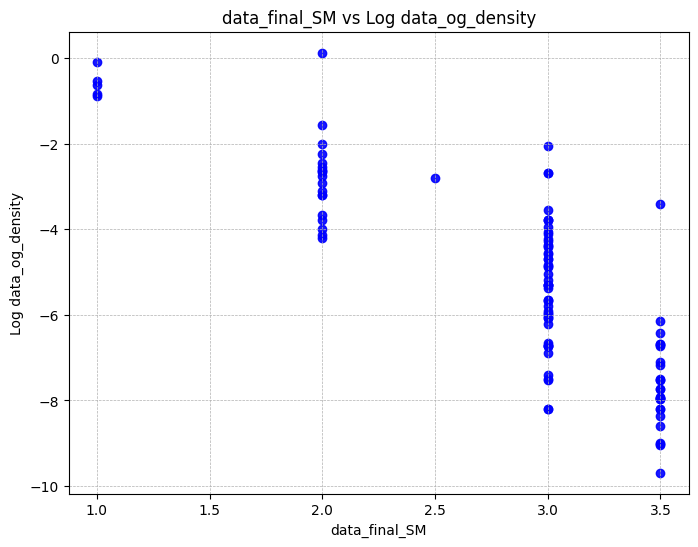

In [19]:
x = data_final_SM
x_label = "data_final_SM"

y = np.log(data_og_density)
y_label = "Log data_og_density"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.8070
Pearson p-value: 7.7584e-25
Kendall Tau coefficient: 0.6671
Kendall p-value: 1.9331e-18


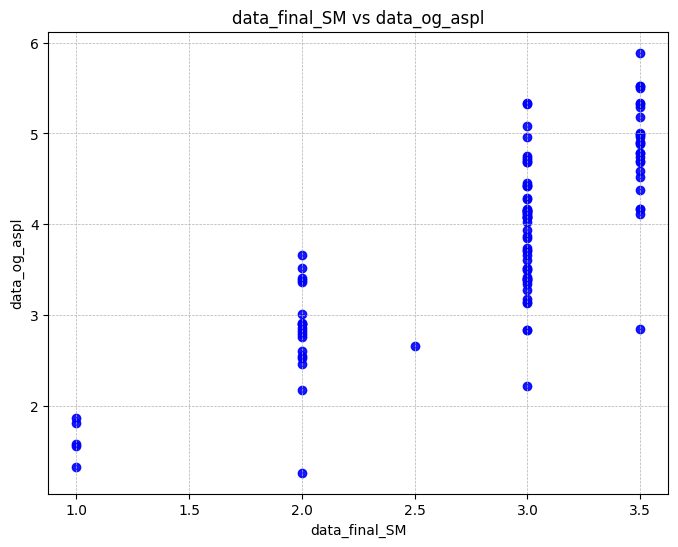

In [20]:
x = data_final_SM
x_label = "data_final_SM"

y = data_og_aspl
y_label = "data_og_aspl"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.8119
Pearson p-value: 2.4003e-25
Kendall Tau coefficient: 0.7209
Kendall p-value: 2.2497e-18


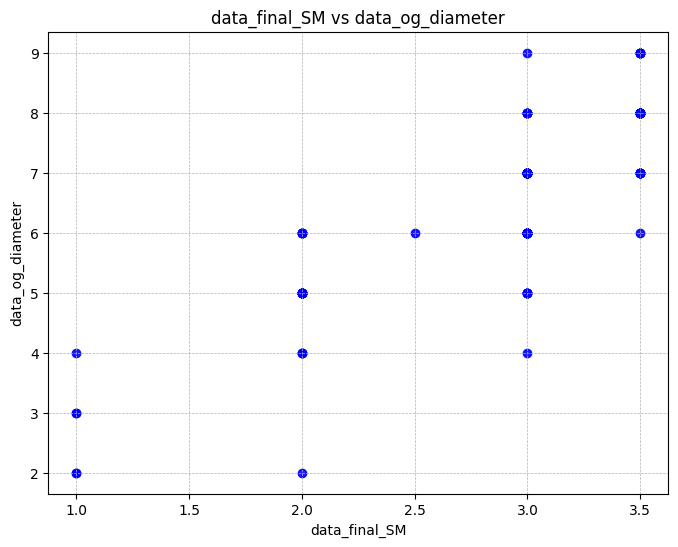

In [21]:
x = data_final_SM
x_label = "data_final_SM"

y = data_og_diameter
y_label = "data_og_diameter"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.3391
Pearson p-value: 4.5866e-04
Kendall Tau coefficient: -0.2900
Kendall p-value: 9.4243e-04


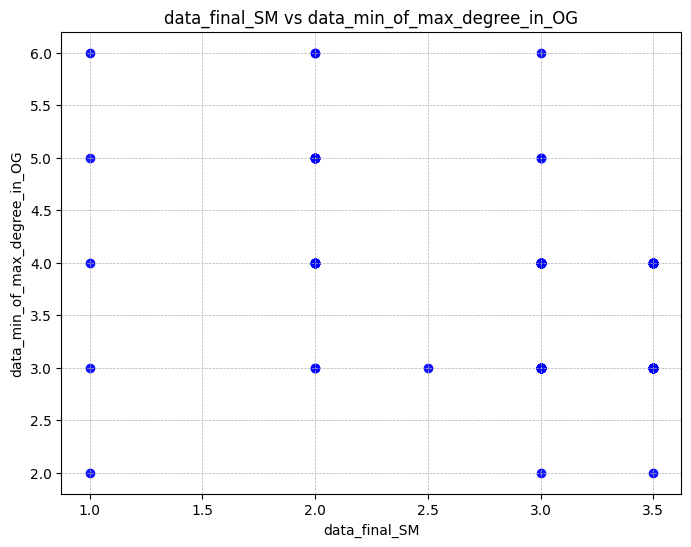

In [22]:
x = data_final_SM
x_label = "data_final_SM"

y = data_min_of_max_degree_in_OG
y_label = "data_min_of_max_degree_in_OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.8662
Pearson p-value: 3.4230e-32
Kendall Tau coefficient: 0.7219
Kendall p-value: 4.3059e-18


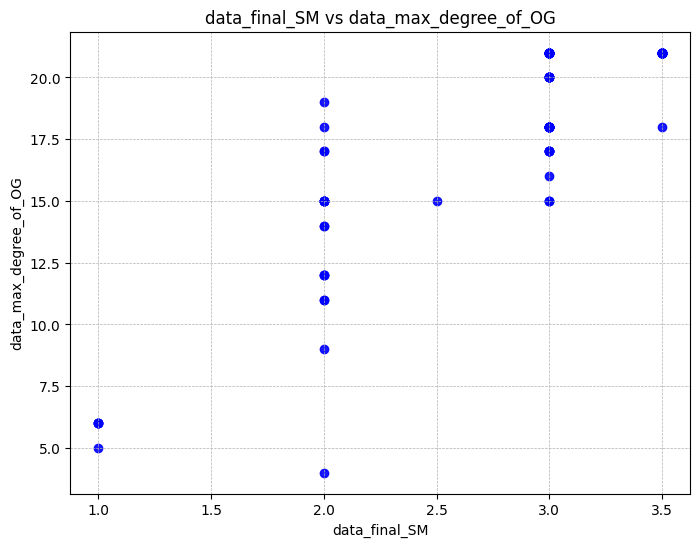

In [23]:
x = data_final_SM
x_label = "data_final_SM"

y = data_max_degree_of_OG
y_label = "data_max_degree_of_OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.2970
Pearson p-value: 2.3123e-03
Kendall Tau coefficient: -0.2358
Kendall p-value: 3.7842e-03


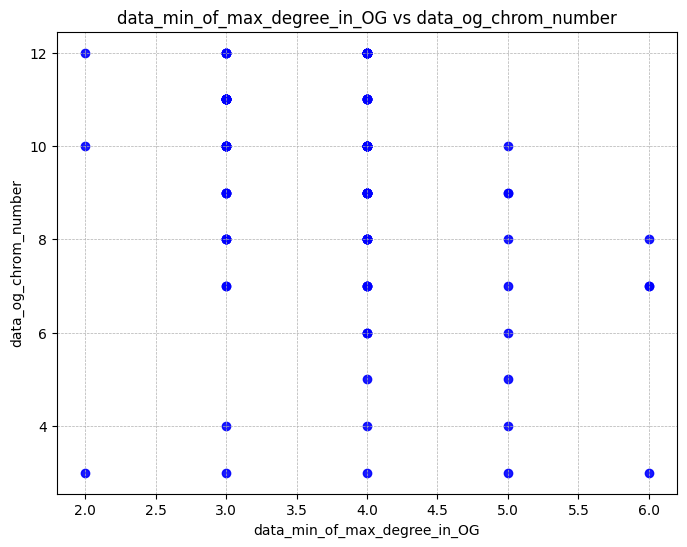

In [24]:
x = data_min_of_max_degree_in_OG
x_label = "data_min_of_max_degree_in_OG"

y = data_og_chrom_number
y_label = "data_og_chrom_number"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.4193
Pearson p-value: 1.0392e-05
Kendall Tau coefficient: -0.3776
Kendall p-value: 9.4418e-07


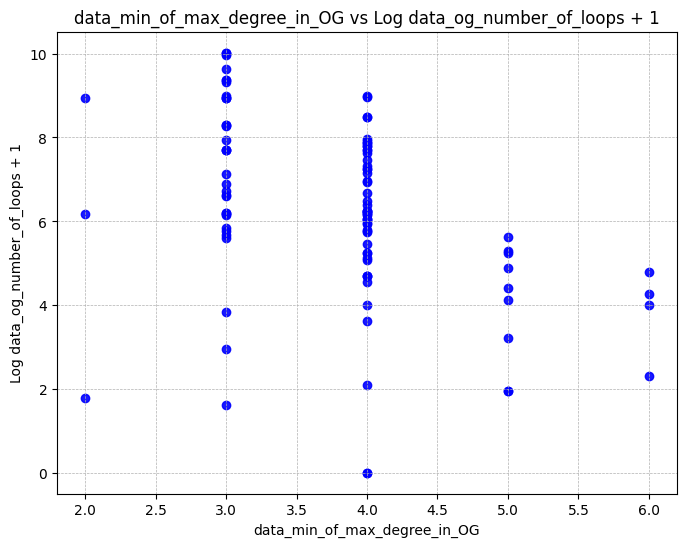

In [25]:
x = data_min_of_max_degree_in_OG
x_label = "data_min_of_max_degree_in_OG"

y = np.log(data_og_number_of_loops+1)
y_label = "Log data_og_number_of_loops + 1"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.2333
Pearson p-value: 1.7686e-02
Kendall Tau coefficient: -0.2003
Kendall p-value: 3.2430e-02


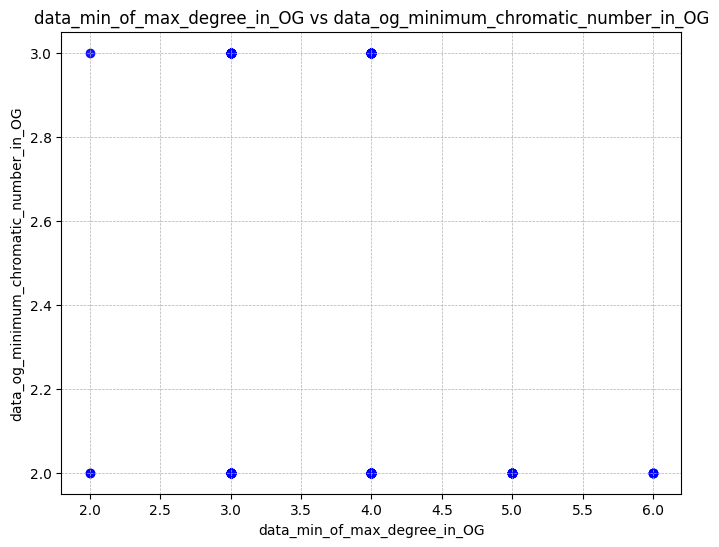

In [26]:
x = data_min_of_max_degree_in_OG
x_label = "data_min_of_max_degree_in_OG"

y = data_og_minimum_chromatic_number_in_OG
y_label = "data_og_minimum_chromatic_number_in_OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.4320
Pearson p-value: 5.2019e-06
Kendall Tau coefficient: 0.3613
Kendall p-value: 2.6520e-06


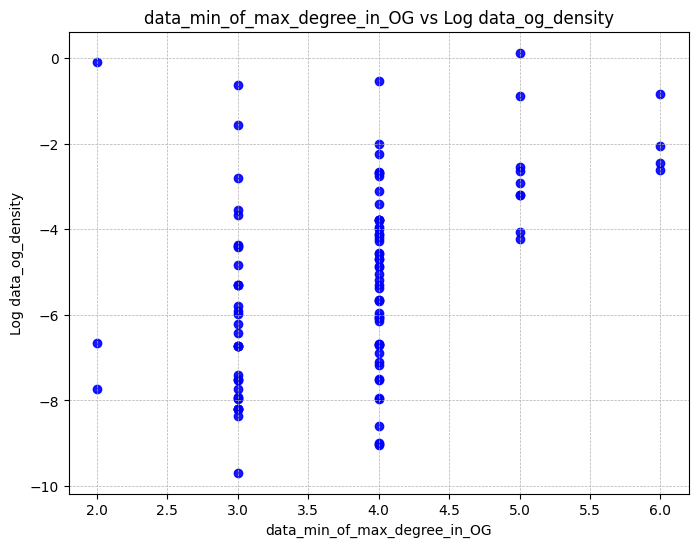

In [27]:
x = data_min_of_max_degree_in_OG
x_label = "data_min_of_max_degree_in_OG"

y = np.log(data_og_density)
y_label = "Log data_og_density"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.4686
Pearson p-value: 5.9628e-07
Kendall Tau coefficient: -0.4071
Kendall p-value: 1.1968e-07


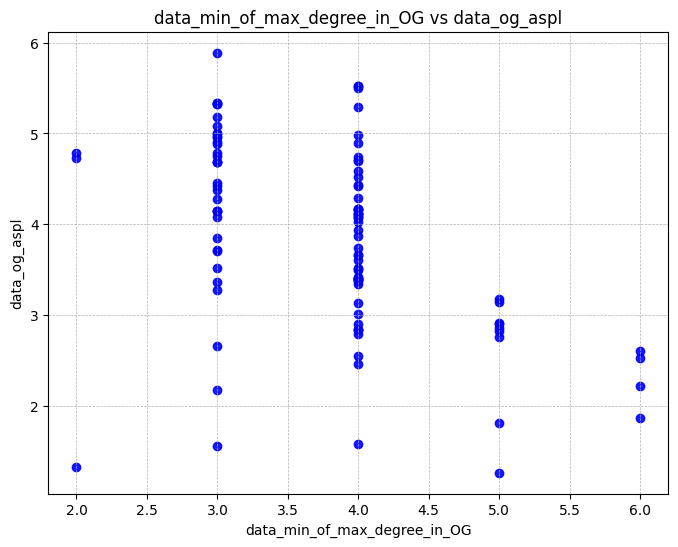

In [28]:
x = data_min_of_max_degree_in_OG
x_label = "data_min_of_max_degree_in_OG"

y = data_og_aspl
y_label = "data_og_aspl"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.4371
Pearson p-value: 3.9151e-06
Kendall Tau coefficient: -0.4469
Kendall p-value: 8.0031e-08


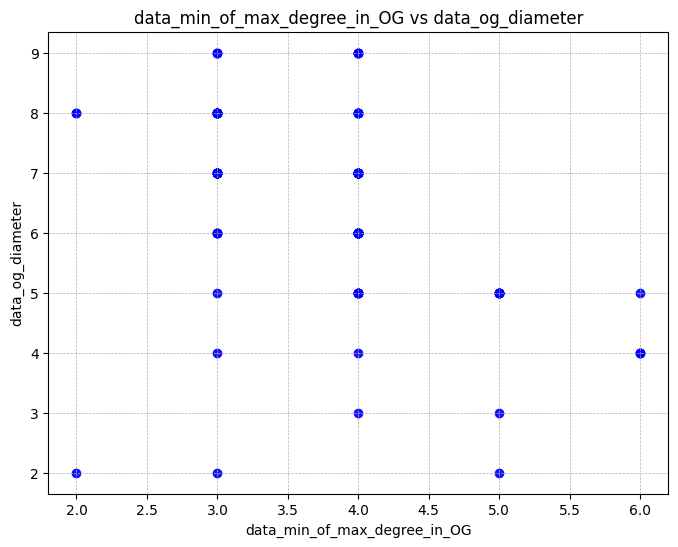

In [29]:
x = data_min_of_max_degree_in_OG
x_label = "data_min_of_max_degree_in_OG"

y = data_og_diameter
y_label = "data_og_diameter"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.9160
Pearson p-value: 7.3075e-42
Kendall Tau coefficient: 0.8114
Kendall p-value: 9.5732e-26


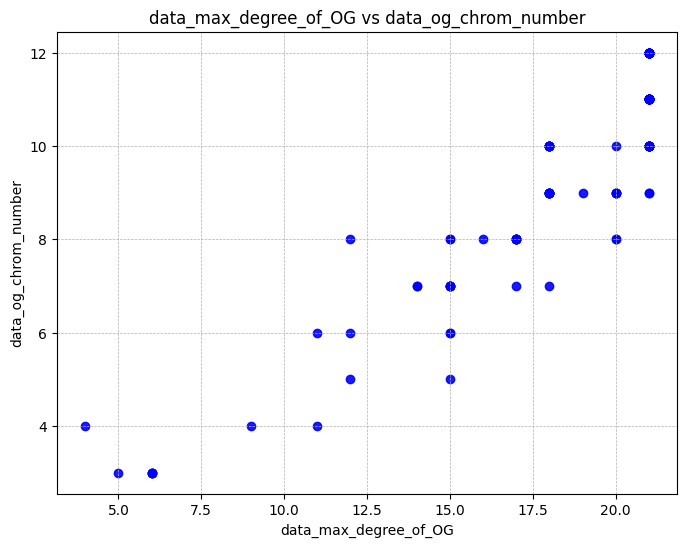

In [30]:
x = data_max_degree_of_OG
x_label = "data_max_degree_of_OG"

y = data_og_chrom_number
y_label = "data_og_chrom_number"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.7290
Pearson p-value: 2.5403e-18
Kendall Tau coefficient: 0.5702
Kendall p-value: 6.5095e-15


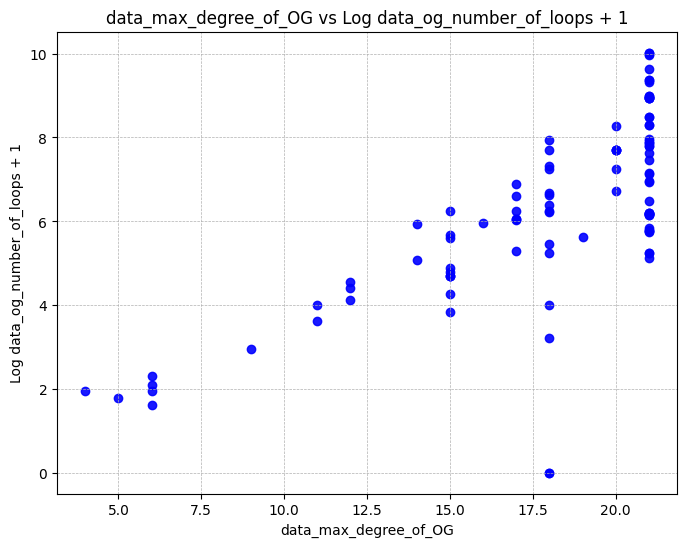

In [31]:
x = data_max_degree_of_OG
x_label = "data_max_degree_of_OG"

y = np.log(data_og_number_of_loops+1)
y_label = "Log data_og_number_of_loops + 1"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.5074
Pearson p-value: 4.5003e-08
Kendall Tau coefficient: 0.5479
Kendall p-value: 7.1337e-10


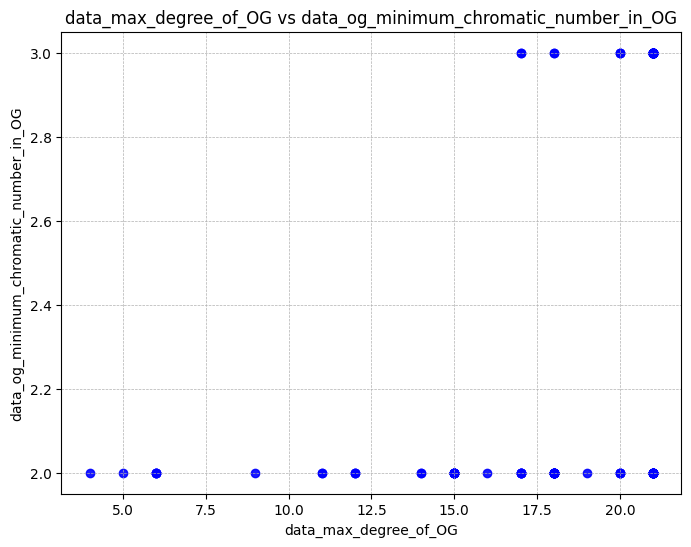

In [32]:
x = data_max_degree_of_OG
x_label = "data_max_degree_of_OG"

y = data_og_minimum_chromatic_number_in_OG
y_label = "data_og_minimum_chromatic_number_in_OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.8934
Pearson p-value: 7.2046e-37
Kendall Tau coefficient: -0.7629
Kendall p-value: 1.6398e-25


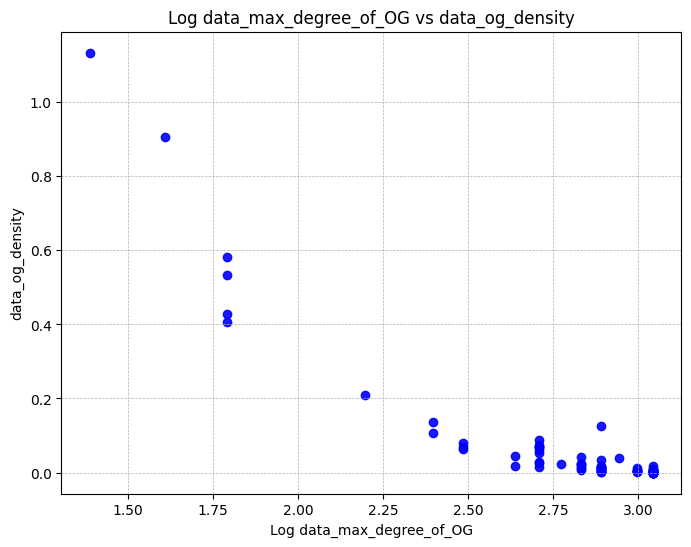

In [33]:
x = np.log(data_max_degree_of_OG)
x_label = "Log data_max_degree_of_OG"

y = data_og_density
y_label = "data_og_density"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.8504
Pearson p-value: 6.3132e-30
Kendall Tau coefficient: 0.7075
Kendall p-value: 3.4954e-22


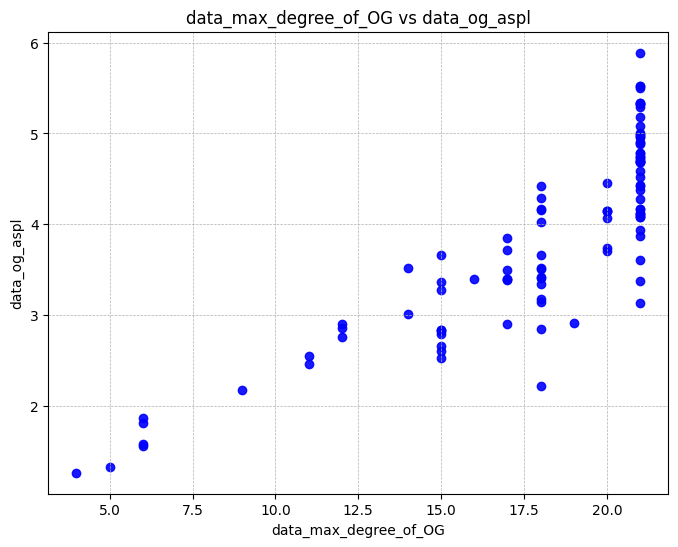

In [34]:
x = data_max_degree_of_OG
x_label = "data_max_degree_of_OG"

y = data_og_aspl
y_label = "data_og_aspl"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.8491
Pearson p-value: 9.3072e-30
Kendall Tau coefficient: 0.7358
Kendall p-value: 1.3521e-20


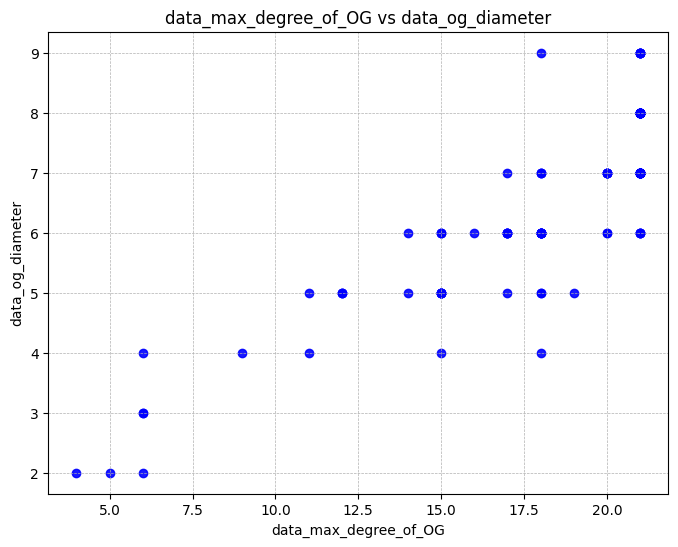

In [35]:
x = data_max_degree_of_OG
x_label = "data_max_degree_of_OG"

y = data_og_diameter
y_label = "data_og_diameter"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.3017
Pearson p-value: 1.9561e-03
Kendall Tau coefficient: -0.2938
Kendall p-value: 4.7609e-04


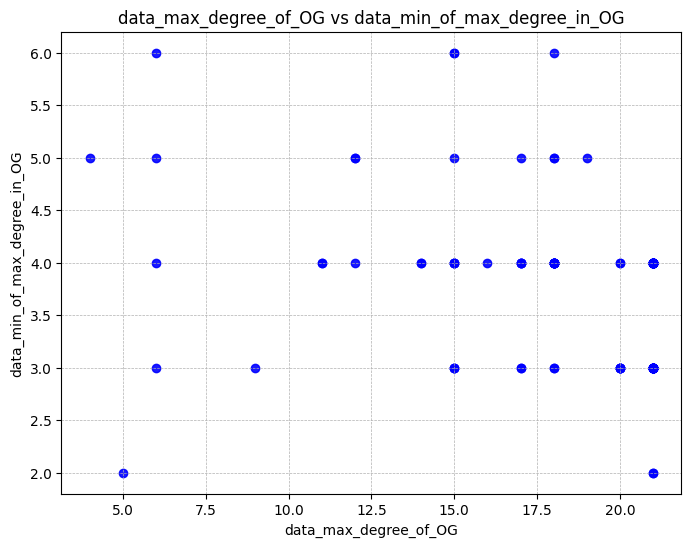

In [36]:
x = data_max_degree_of_OG
x_label = "data_max_degree_of_OG"

y = data_min_of_max_degree_in_OG
y_label = "data_min_of_max_degree_in_OG"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.9400
Pearson p-value: 5.8674e-49
Kendall Tau coefficient: 0.8387
Kendall p-value: 4.4827e-31


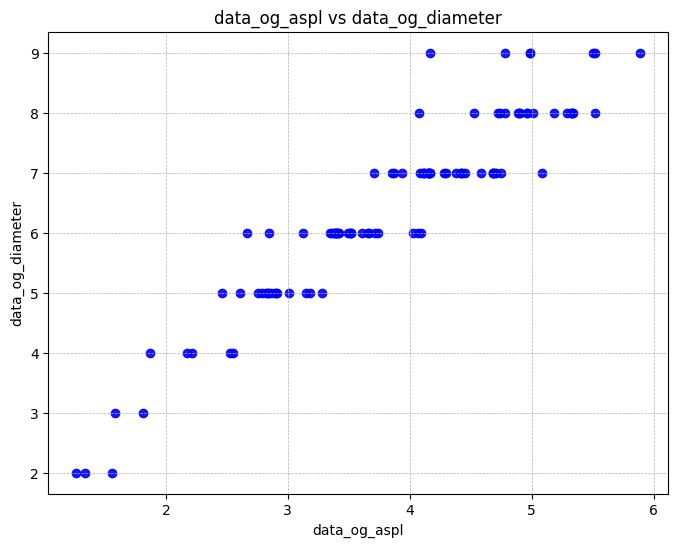

In [37]:
#16
x = data_og_aspl
x_label = "data_og_aspl"

y = data_og_diameter
y_label = "data_og_diameter"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.9352
Pearson p-value: 2.4404e-47
Kendall Tau coefficient: -0.8363
Kendall p-value: 6.9622e-31


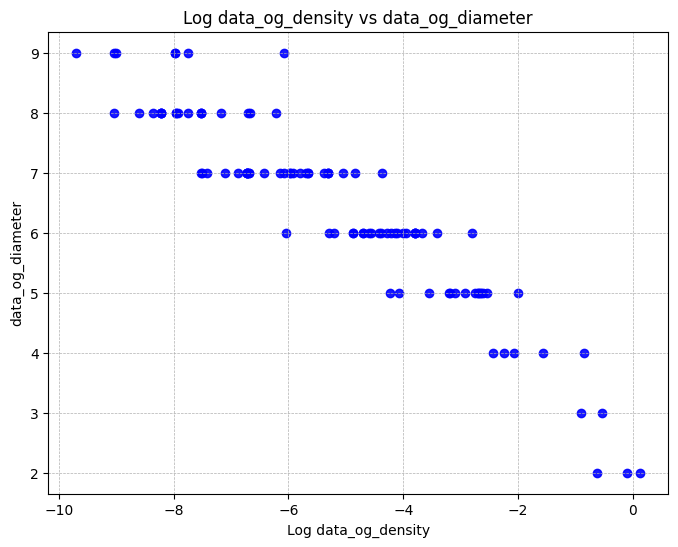

In [38]:
#15
x = np.log(data_og_density)
x_label = "Log data_og_density"

y = data_og_diameter
y_label = "data_og_diameter"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: -0.9877
Pearson p-value: 3.3559e-83
Kendall Tau coefficient: -0.8997
Kendall p-value: 3.0521e-41


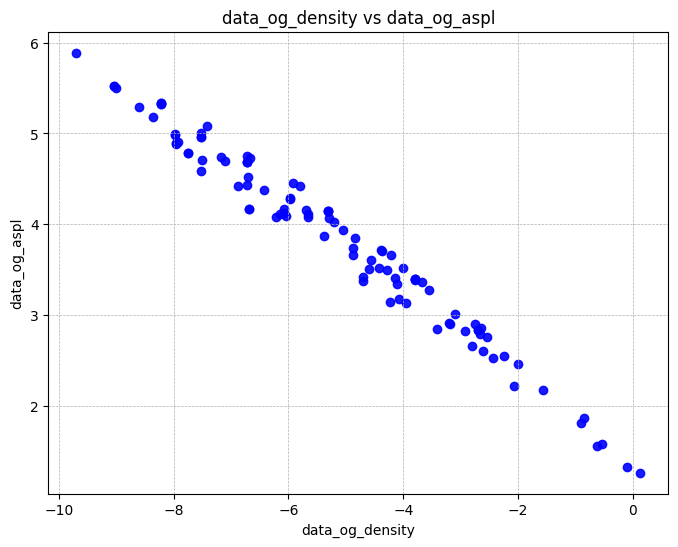

In [39]:
#14
x = np.log(data_og_density)
x_label = "data_og_density"

y = data_og_aspl
y_label = "data_og_aspl"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.5492
Pearson p-value: 1.8895e-09
Kendall Tau coefficient: 0.5182
Kendall p-value: 3.9255e-09


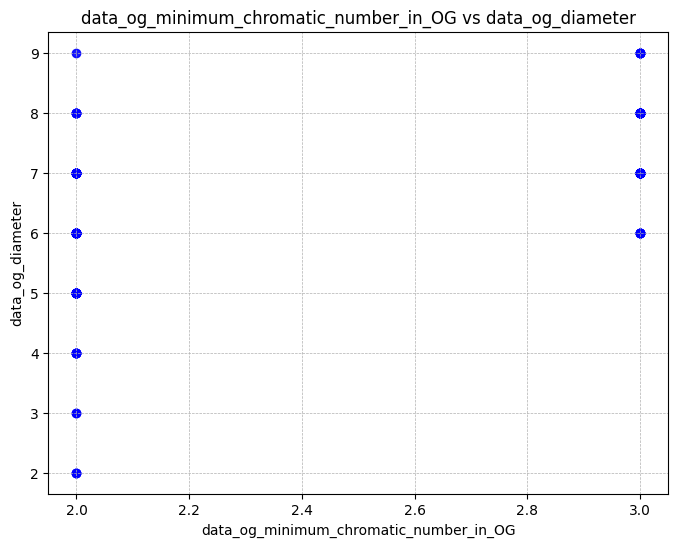

In [40]:
#13
x = data_og_minimum_chromatic_number_in_OG
x_label = "data_og_minimum_chromatic_number_in_OG"

y = data_og_diameter
y_label = "data_og_diameter"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.6026
Pearson p-value: 1.6500e-11
Kendall Tau coefficient: 0.5125
Kendall p-value: 2.8596e-10


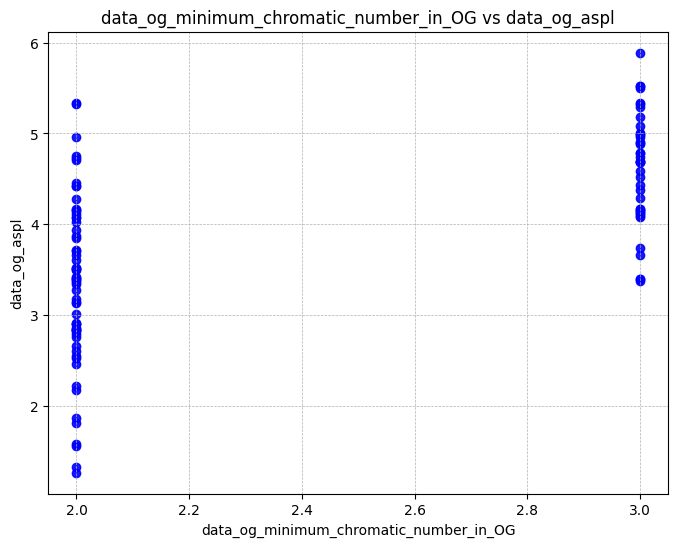

In [41]:
#12
x = data_og_minimum_chromatic_number_in_OG
x_label = "data_og_minimum_chromatic_number_in_OG"

y = data_og_aspl
y_label = "data_og_aspl"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: -0.6377
Pearson p-value: 4.3827e-13
Kendall Tau coefficient: -0.5385
Kendall p-value: 3.5214e-11


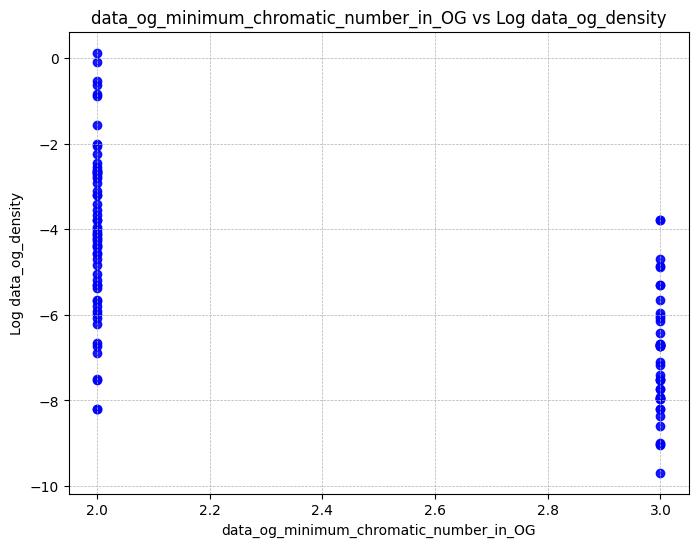

In [42]:
#11
x = data_og_minimum_chromatic_number_in_OG
x_label = "data_og_minimum_chromatic_number_in_OG"

y = np.log(data_og_density)
y_label = "Log data_og_density"
    
plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.6314
Pearson p-value: 8.6450e-13
Kendall Tau coefficient: 0.5242
Kendall p-value: 4.6549e-13


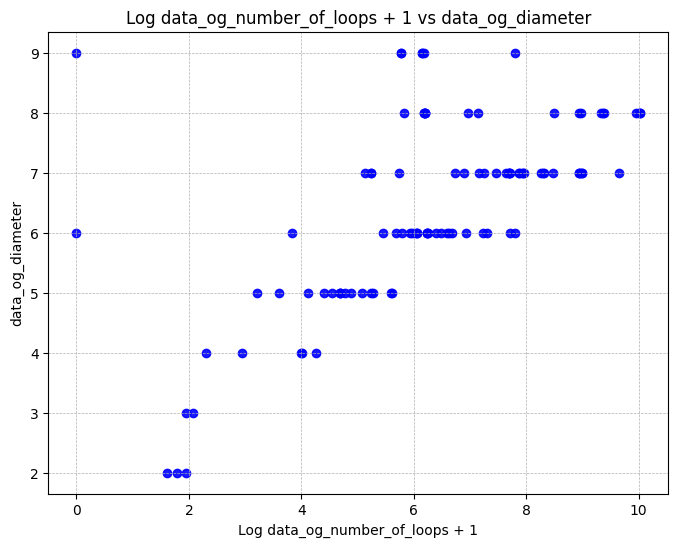

In [43]:
#9
x = np.log(data_og_number_of_loops+1)
x_label = "Log data_og_number_of_loops + 1"

y = data_og_diameter
y_label = "data_og_diameter"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.7530
Pearson p-value: 4.5986e-20
Kendall Tau coefficient: 0.6009
Kendall p-value: 2.8531e-19


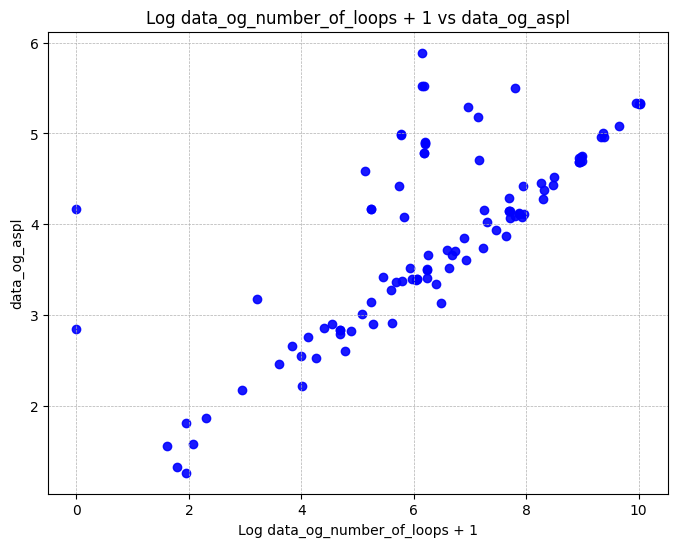

In [44]:
#8
x = np.log(data_og_number_of_loops+1)
x_label = "Log data_og_number_of_loops + 1"

y = data_og_aspl
y_label = "data_og_aspl"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: -0.6914
Pearson p-value: 6.2200e-16
Kendall Tau coefficient: -0.5668
Kendall p-value: 2.6418e-17


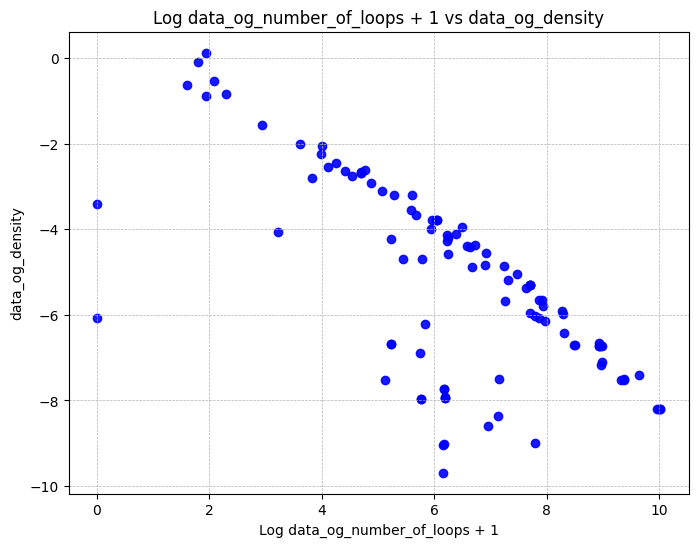

In [45]:
#7
x = np.log(data_og_number_of_loops+1)
x_label = "Log data_og_number_of_loops + 1"

y = np.log(data_og_density)
y_label = "data_og_density"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.4162
Pearson p-value: 1.2313e-05
Kendall Tau coefficient: 0.3356
Kendall p-value: 3.7316e-05


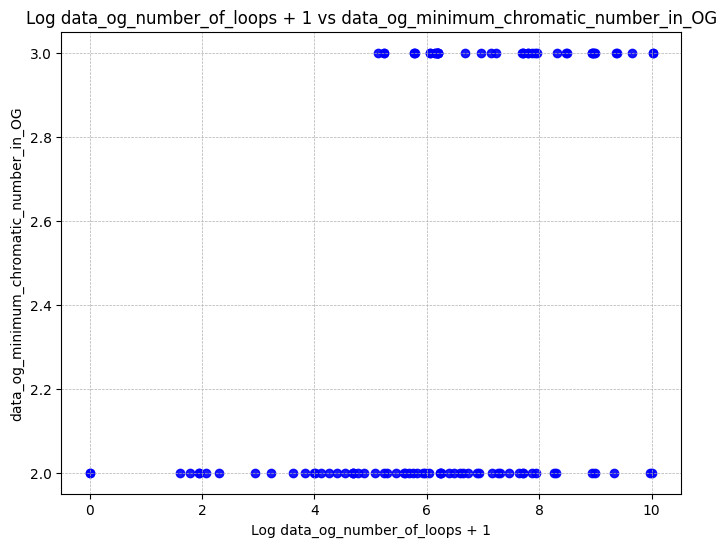

In [46]:
#6
#use offset for log(x+1)
x = np.log(data_og_number_of_loops+1)
x_label = "Log data_og_number_of_loops + 1"

y = data_og_minimum_chromatic_number_in_OG
y_label = "data_og_minimum_chromatic_number_in_OG"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.8497
Pearson p-value: 7.9040e-30
Kendall Tau coefficient: 0.7268
Kendall p-value: 2.3458e-21


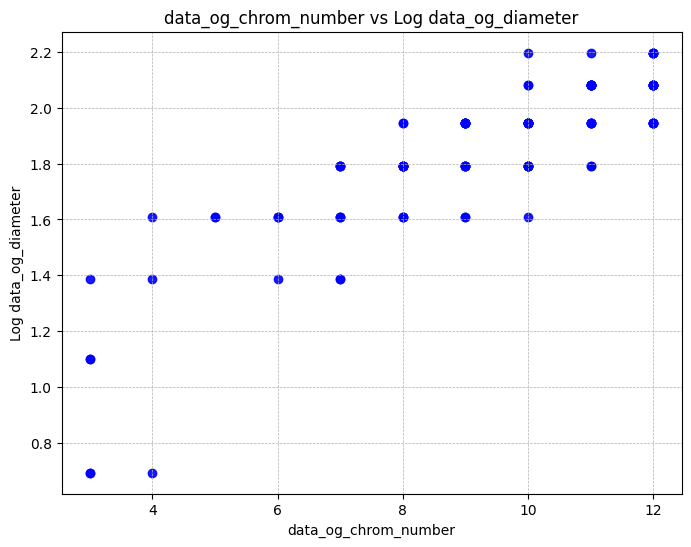

In [47]:
#5
x = data_og_chrom_number
x_label = "data_og_chrom_number"

y = np.log(data_og_diameter)
y_label = "Log data_og_diameter"

plot_coef_and_find_pearson(x,y,x_label,y_label)
 

Pearson correlation coefficient: 0.8824
Pearson p-value: 7.5138e-35
Kendall Tau coefficient: 0.6898
Kendall p-value: 1.8876e-22


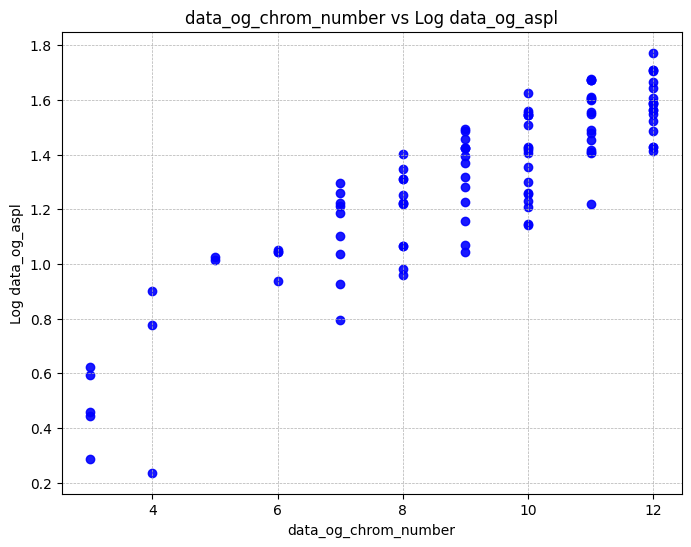

In [48]:
#4
x = data_og_chrom_number
x_label = "data_og_chrom_number"

y = np.log(data_og_aspl)
y_label = "Log data_og_aspl"

plot_coef_and_find_pearson(x,y,x_label,y_label)


Pearson correlation coefficient: -0.9101
Pearson p-value: 1.9627e-40
Kendall Tau coefficient: -0.7760
Kendall p-value: 5.8689e-28


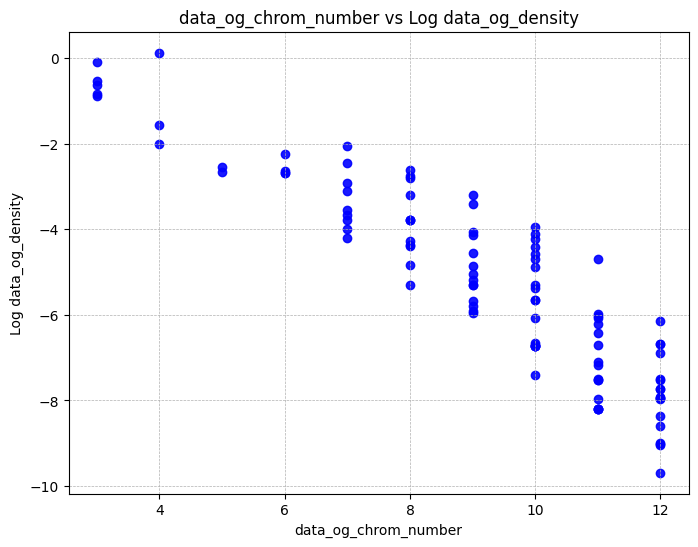

In [49]:
#3
x = data_og_chrom_number
x_label = "data_og_chrom_number"

y = np.log(data_og_density)
y_label = "Log data_og_density"

plot_coef_and_find_pearson(x,y,x_label,y_label)


Pearson correlation coefficient: 0.5845
Pearson p-value: 9.0276e-11
Kendall Tau coefficient: 0.5580
Kendall p-value: 9.0346e-11


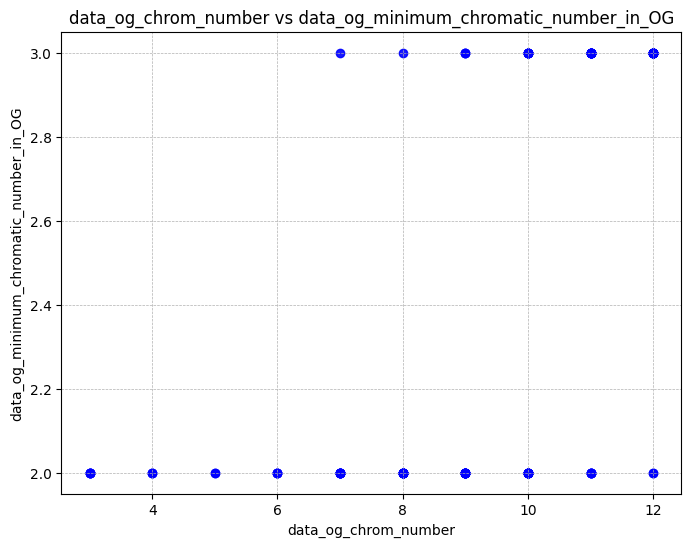

In [50]:
#2
x = data_og_chrom_number
x_label = "data_og_chrom_number"

y = data_og_minimum_chromatic_number_in_OG
y_label = "data_og_minimum_chromatic_number_in_OG"

plot_coef_and_find_pearson(x,y,x_label,y_label)

Pearson correlation coefficient: 0.6159
Pearson p-value: 4.3960e-12
Kendall Tau coefficient: 0.4002
Kendall p-value: 1.6362e-08


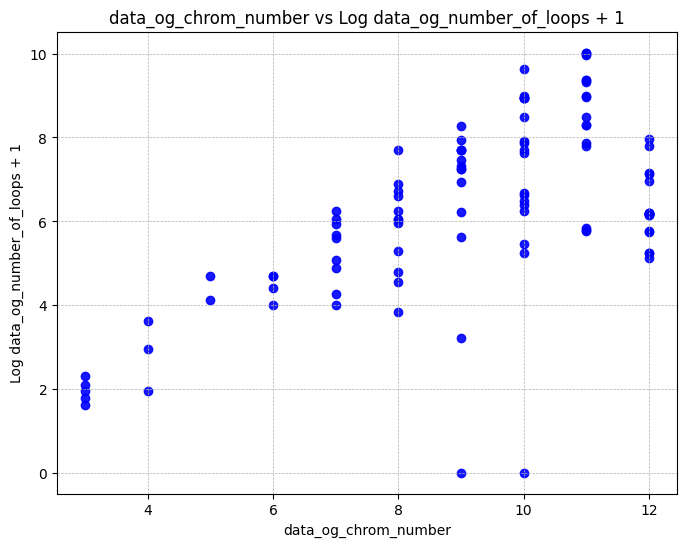

In [51]:
#1
x = data_og_chrom_number
x_label = "data_og_chrom_number"

# Offset needed to avoid log(0)
y = np.log(data_og_number_of_loops + 1)
y_label = "Log data_og_number_of_loops + 1"

plot_coef_and_find_pearson(x,y,x_label,y_label)


In [52]:
correlation_dict

{'data_final_SM vs data_og_chrom_number': {'pearson_coef': 0.8555256267105666,
  'pearson_pvalue': 1.2358277429753501e-30,
  'kendall_coef': 0.7435670139873198,
  'kendall_pvalue': 2.926427582686951e-20},
 'data_final_SM vs Log data_og_number_of_loops + 1': {'pearson_coef': 0.5793082286103854,
  'pearson_pvalue': 1.4473337840098374e-10,
  'kendall_coef': 0.38926006393934326,
  'kendall_pvalue': 3.3073855644109e-07},
 'data_final_SM vs data_og_minimum_chromatic_number_in_OG': {'pearson_coef': 0.5910431669427071,
  'pearson_pvalue': 4.9454216347841046e-11,
  'kendall_coef': 0.6575025269466822,
  'kendall_pvalue': 1.3172176530769392e-12},
 'data_final_SM vs Log data_og_density': {'pearson_coef': -0.8240048502675194,
  'pearson_pvalue': 1.1492136510803695e-26,
  'kendall_coef': -0.7064254779692553,
  'kendall_pvalue': 1.7950277799895334e-20},
 'data_final_SM vs data_og_aspl': {'pearson_coef': 0.8069691905131603,
  'pearson_pvalue': 7.758444946847442e-25,
  'kendall_coef': 0.667121267633514

Here we are going to use the pandas library to create latex tables to use in the draft. 

In [53]:
import pandas as pd


In [54]:
# Convert to DataFrame for easier processing
df = pd.DataFrame.from_dict(correlation_dict, orient='index')

# Function to format p-values in LaTeX format with $ signs
def format_pvalue_strong_cor(pvalue):
    """
    Formats a p-value for strong correlation analysis into a LaTeX-friendly string.

    - If the p-value is less than 0.001, it is formatted using scientific notation 
      with LaTeX syntax (e.g., $2.35\\times10^{-4}$).
    - Otherwise, it is formatted to two decimal places (e.g., $0.02$).

    Parameters:
    pvalue (float): The p-value to format.

    Returns:
    str: A LaTeX-formatted string representing the p-value.
    """
    if pvalue < 1e-3:
        latex_pvalue = "{:.2e}".format(pvalue)
        base, exponent = latex_pvalue.split('e')
        return f"${base}\\times10^{{{int(exponent)}}}$"
    else:
        return f"${pvalue:.2f}$"


# Apply filtering: Keep only rows where |pearson coefficient| > 0.8
df_filtered = df[abs(df['pearson_coef']) > 0.8]  # Corrected column name

# Apply formatting to the p-value column
df_filtered['pearson_pvalue'] = df_filtered['pearson_pvalue'].apply(format_pvalue_strong_cor)

# Display the formatted dataframe in LaTeX format
print(df_filtered.to_latex())

\begin{tabular}{lrlrr}
\toprule
 & pearson_coef & pearson_pvalue & kendall_coef & kendall_pvalue \\
\midrule
data_final_SM vs data_og_chrom_number & 0.855526 & $1.24\times10^{-30}$ & 0.743567 & 0.000000 \\
data_final_SM vs Log data_og_density & -0.824005 & $1.15\times10^{-26}$ & -0.706425 & 0.000000 \\
data_final_SM vs data_og_aspl & 0.806969 & $7.76\times10^{-25}$ & 0.667121 & 0.000000 \\
data_final_SM vs data_og_diameter & 0.811892 & $2.40\times10^{-25}$ & 0.720922 & 0.000000 \\
data_final_SM vs data_max_degree_of_OG & 0.866165 & $3.42\times10^{-32}$ & 0.721921 & 0.000000 \\
data_max_degree_of_OG vs data_og_chrom_number & 0.916037 & $7.31\times10^{-42}$ & 0.811420 & 0.000000 \\
Log data_max_degree_of_OG vs data_og_density & -0.893356 & $7.20\times10^{-37}$ & -0.762941 & 0.000000 \\
data_max_degree_of_OG vs data_og_aspl & 0.850387 & $6.31\times10^{-30}$ & 0.707545 & 0.000000 \\
data_max_degree_of_OG vs data_og_diameter & 0.849134 & $9.31\times10^{-30}$ & 0.735816 & 0.000000 \\
data_og

/var/folders/3d/sh6jhl692_90_wc18d07vyww0000gn/T/ipykernel_89887/503481391.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['pearson_pvalue'] = df_filtered['pearson_pvalue'].apply(format_pvalue_strong_cor)


In [55]:
# Here, we are going to start creating the table where the statistical properties of all the observables are presented.
# Initialize the dictionary
simple_observables = {}

# Loop through each dataset name in help_array
for dataset_name in help_array:
    # Retrieve the dataset using globals()
    dataset = globals().get(dataset_name)
    
    if dataset is not None:
        # Call the stat_properties function and get the statistical properties
        description = dataset_name.replace("_", " ").title()  # Generate a description from the name
        stat_results = stat_properties(dataset, description, print_resutls=False)  # Get the results without printing
        
        # Store the results in 'simple_observables'
        simple_observables[dataset_name] = {
            "mean": stat_results[0],
            "std_dev": stat_results[1],
            "variance": stat_results[2],
            "median": stat_results[3],
            "mode": stat_results[4],
            "range": stat_results[5],
            "iqr": stat_results[6],
            "skewness": stat_results[7],
            "kurtosis": stat_results[8]
        }
    else:
        print(f"Dataset {dataset_name} not found.")


In [56]:
simple_observables["data_og_density"]

{'mean': 0.057126667518963795,
 'std_dev': 0.1675274906939736,
 'variance': 0.028065460138219412,
 'median': 0.004951024085997479,
 'mode': 0.000270973359441397,
 'range': 1.1332714314018042,
 'iqr': 0.022967648267354035,
 'skewness': 4.532857655252505,
 'kurtosis': 21.899346636427662}

In [57]:
#Statistical properties of each observable. Table from paper

# Convert to DataFrame
df = pd.DataFrame.from_dict(simple_observables, orient='index')

def format_value(value, row_name, column_name):
    """
    Formats a value into a LaTeX-friendly string:
    - 4 decimals for 'data_og_density' row
    - 2 decimals for other float values
    - integers and others as-is
    """
    if isinstance(value, float):
        if row_name == "data_og_density":
            return f"${value:.4f}$"  # special case
        else:
            return f"${value:.2f}$"
    elif isinstance(value, int):
        return f"${value}$"
    else:
        return str(value)


# Apply formatting with column-aware lambda
# Correct application of format_value with row and column info
for row_name in df.index:
    for column_name in df.columns:
        value = df.loc[row_name, column_name]
        df.loc[row_name, column_name] = format_value(value, row_name, column_name)


# Display LaTeX-formatted table
print(df.to_latex())


\begin{tabular}{llllllllll}
\toprule
 & mean & std_dev & variance & median & mode & range & iqr & skewness & kurtosis \\
\midrule
data_og_chrom_number & $9.12$ & $2.45$ & $6.01$ & $10.00$ & $10.00$ & $9.00$ & $3.00$ & $-0.89$ & $0.14$ \\
data_og_number_of_loops & $2674.96$ & $4912.78$ & $24135405.61$ & $507.00$ & $108.00$ & $22632.00$ & $2245.00$ & $2.77$ & $7.46$ \\
data_og_minimum_chromatic_number_in_OG & $2.40$ & $0.49$ & $0.24$ & $2.00$ & $2.00$ & $1.00$ & $1.00$ & $0.42$ & $-1.83$ \\
data_og_density & $0.0571$ & $0.1675$ & $0.0281$ & $0.0050$ & $0.0003$ & $1.1333$ & $0.0230$ & $4.5329$ & $21.8993$ \\
data_og_aspl & $3.85$ & $1.03$ & $1.05$ & $4.07$ & $2.84$ & $4.62$ & $1.53$ & $-0.40$ & $-0.37$ \\
data_og_diameter & $6.42$ & $1.55$ & $2.40$ & $7.00$ & $7.00$ & $7.00$ & $1.00$ & $-0.67$ & $0.50$ \\
data_min_of_max_degree_in_OG & $3.77$ & $0.80$ & $0.64$ & $4.00$ & $4.00$ & $4.00$ & $1.00$ & $0.56$ & $0.78$ \\
data_max_degree_of_OG & $17.96$ & $4.21$ & $17.69$ & $20.00$ & $21.00$ & 

/var/folders/3d/sh6jhl692_90_wc18d07vyww0000gn/T/ipykernel_89887/3395386597.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '$9.12$' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[row_name, column_name] = format_value(value, row_name, column_name)
/var/folders/3d/sh6jhl692_90_wc18d07vyww0000gn/T/ipykernel_89887/3395386597.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '$2.45$' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[row_name, column_name] = format_value(value, row_name, column_name)
/var/folders/3d/sh6jhl692_90_wc18d07vyww0000gn/T/ipykernel_89887/3395386597.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '$6.01$' has dtyp

Here, we start creating the dictionary to prepare the table to present the values of the observables for every entanglement class.

In [58]:
# Initialize the 'dict_orbits_data' dictionary
dict_orbits_data = {}

# Loop through each dataset name in help_array
for dataset_name in help_array:
    # Retrieve the dataset using globals()
    dataset = globals().get(dataset_name)
    
    # Ensure that the dataset is a numpy array and is not empty
    if dataset is not None and dataset.size > 0:
        # Initialize orbit data for each dataset if not already initialized
        for i in range(len(dataset)):
            if f"orbit_{i}" not in dict_orbits_data:
                dict_orbits_data[f"orbit_{i}"] = {}
            # Add the data for the current dataset into the dictionary
            dict_orbits_data[f"orbit_{i}"][dataset_name] = dataset[i]
            
            
            
dict_orbits_data

{'orbit_0': {'data_og_chrom_number': 3,
  'data_og_number_of_loops': 5,
  'data_og_minimum_chromatic_number_in_OG': 2,
  'data_og_density': 0.9047619047619048,
  'data_og_aspl': 1.3333333333333333,
  'data_og_diameter': 2,
  'data_min_of_max_degree_in_OG': 2,
  'data_max_degree_of_OG': 5,
  'data_final_SM': 1.0},
 'orbit_1': {'data_og_chrom_number': 3,
  'data_og_number_of_loops': 4,
  'data_og_minimum_chromatic_number_in_OG': 2,
  'data_og_density': 0.5333333333333333,
  'data_og_aspl': 1.5555555555555556,
  'data_og_diameter': 2,
  'data_min_of_max_degree_in_OG': 3,
  'data_max_degree_of_OG': 6,
  'data_final_SM': 1.0},
 'orbit_2': {'data_og_chrom_number': 4,
  'data_og_number_of_loops': 18,
  'data_og_minimum_chromatic_number_in_OG': 2,
  'data_og_density': 0.21021021021021022,
  'data_og_aspl': 2.175675675675676,
  'data_og_diameter': 4,
  'data_min_of_max_degree_in_OG': 3,
  'data_max_degree_of_OG': 9,
  'data_final_SM': 2.0},
 'orbit_3': {'data_og_chrom_number': 4,
  'data_og_num

In [60]:
# Get an array with the number of nodes and vertices 
data_vertices_og = []
n = 7
d = 3
# Load the graph using NetworkX
file_path = f"orbits_d{d}_n{n}_separated_sorted/orbit_0"

nx_graph = nx.read_edgelist(file_path, nodetype=int)
nodes = len(list(nx_graph.nodes())) 
print("Number of nodes:",nodes)

for cnt in range(3,n+1):
    print(f"------------------------------------Start calculating for n={cnt}------------------------------------")
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated_sorted")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number
    for file in files_for_given_orbit:
        g=nx.read_edgelist(f"orbits_d{d}_n{cnt}_separated_sorted/{file}", nodetype=int)
        nodes = len(list(g.nodes()))
        data_vertices_og.append(nodes)
        print(f"OG nodes for {file}: {nodes}")

data_vertices_og 
        
        


Number of nodes: 15
------------------------------------Start calculating for n=3------------------------------------
OG nodes for orbit_0: 7
------------------------------------Start calculating for n=4------------------------------------
OG nodes for orbit_0: 10
OG nodes for orbit_1: 37
OG nodes for orbit_2: 6
------------------------------------Start calculating for n=5------------------------------------
OG nodes for orbit_0: 11
OG nodes for orbit_1: 88
OG nodes for orbit_2: 255
OG nodes for orbit_3: 219
OG nodes for orbit_4: 139
------------------------------------Start calculating for n=6------------------------------------
OG nodes for orbit_0: 14
OG nodes for orbit_1: 116
OG nodes for orbit_2: 66
OG nodes for orbit_3: 666
OG nodes for orbit_4: 420
OG nodes for orbit_5: 1850
OG nodes for orbit_6: 162
OG nodes for orbit_7: 164
OG nodes for orbit_8: 4698
OG nodes for orbit_9: 7572
OG nodes for orbit_10: 180
OG nodes for orbit_11: 331
OG nodes for orbit_12: 164
OG nodes for orbit_1

[7,
 10,
 37,
 6,
 11,
 88,
 255,
 219,
 139,
 14,
 116,
 66,
 666,
 420,
 1850,
 162,
 164,
 4698,
 7572,
 180,
 331,
 164,
 1008,
 980,
 1892,
 1200,
 1572,
 119,
 462,
 940,
 15,
 137,
 156,
 852,
 483,
 565,
 1069,
 5052,
 5853,
 1155,
 13923,
 576,
 577,
 6451,
 3144,
 14703,
 3153,
 14724,
 71046,
 35091,
 48207,
 239,
 896,
 577,
 2695,
 1597,
 3132,
 4872,
 1360,
 3153,
 14724,
 14679,
 35418,
 7440,
 48207,
 71244,
 57072,
 71400,
 357,
 7818,
 2162,
 2062,
 29340,
 15600,
 37260,
 2631,
 23634,
 35589,
 11802,
 71400,
 338868,
 1030,
 10084,
 59454,
 19872,
 5016,
 59454,
 170580,
 173784,
 9669,
 4107,
 2136,
 15288,
 88380,
 58908,
 8214,
 24702,
 114528,
 175464,
 58908,
 38388,
 16745,
 16745]

In [61]:
# Get the number of vertices the actual graph states we have
d = 3
n = 7
nodes_of_states = []
for cnt in range(3,n+1):
    print(f"------------------------------------Start calculating for n={cnt}------------------------------------")
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated_sorted")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number
    for file in files_for_given_orbit:
        nodes_of_states.append(cnt)
        
nodes_of_states
        

------------------------------------Start calculating for n=3------------------------------------
------------------------------------Start calculating for n=4------------------------------------
------------------------------------Start calculating for n=5------------------------------------
------------------------------------Start calculating for n=6------------------------------------
------------------------------------Start calculating for n=7------------------------------------


[3,
 4,
 4,
 4,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7]

In [62]:
#Start the process for the SM for the table. Remember we have intervals in some cases and thus care must be taken.
# Load the data from the file
with open("og_data_final/join_sm_in_og.txt", "r") as f:
    data_sm_initial = eval(f.read())
data_sm_initial
# Function use the range for SM values in the table
def flatten_and_modify_table(nested_list):
    """
    Function explained in sm_final_data.py
    """
    flat_list = []
    for item in nested_list:
        if isinstance(item, list):  # If item is a list, check if it needs modification
            if len(item) == 2:  # If the list has exactly two elements, convert to tuple
                flat_list.append(tuple(item))
            else:
                flat_list.extend(flatten_and_modify_table(item))  # Recursively flatten and add to the list
        else:
            flat_list.append(item)  # If it's not a list, just append it
    return flat_list

# Flatten the data with modifications
sm_data_table = flatten_and_modify_table(data_sm_initial)


In [63]:
# Here we will insert the minimum number of edges each representative has.
with open("og_data_final/reps_number_of_edges.txt", "r") as f:
    data_reps_edges = eval(f.read())
len(data_reps_edges)

103

In [64]:
#Create the table
# Convert dict_orbits_data to DataFrame
df = pd.DataFrame.from_dict(dict_orbits_data, orient='index')

# Reset index and rename to 'orbit'
df.reset_index(inplace=True)
df.rename(columns={'index': 'orbit'}, inplace=True)

# Replace orbit labels to start from orbit_1
df['orbit'] = [f"{i+1}" for i in range(len(df))]

# Apply log(x + 1) to the 'data_og_number_of_loops' column
df['data_og_number_of_loops'] = df['data_og_number_of_loops'].apply(lambda x: np.log(x + 1))

df['data_final_SM'] = sm_data_table

# Add the edges/vertices data (you can load or assign this earlier)
# Make sure the number of tuples matches the number of rows in df
df.insert(1, 'n', nodes_of_states)
df.insert(2, 'V', data_vertices_og)
df.insert(3, 'reps_edges', data_reps_edges)

# Function to format numerical values for LaTeX output with column-aware precision
def format_value(value, column):
    """
    Formats a value into a LaTeX-friendly string based on its type and column context.

    - Floats:
        - If the column is 'data_og_density', format with 5 decimal places.
        - Otherwise, format with 2 decimal places.
    - Integers:
        - Display without decimals in LaTeX math mode.
    - Tuples (only if column == 'edges_vertices'):
        - Format as a LaTeX tuple: (a, b) in math mode.
    - Other types:
        - Returned as plain strings.

    Parameters:
    value (int | float | tuple | any): The value to format.
    column (str): The name of the column, used to determine formatting rules.

    Returns:
    str: A LaTeX-friendly string representation of the value.
    """
    if isinstance(value, float):
        if column == 'data_og_density':
            return f"${value:.5f}$"  # 5 decimal places for density
        else:
            return f"${value:.2f}$"  # 2 decimal places for other floats
    elif isinstance(value, int):
        return f"${value}$"  # No decimals for integers
    elif isinstance(value, tuple) and column == 'edges_vertices':
        return f"$({value[0]}, {value[1]})$"  # Format (edges, vertices)
    else:
        return str(value)


# Apply formatting to all relevant columns
for column in df.columns:
    df[column] = df[column].apply(lambda x: format_value(x, column))


# Display the formatted DataFrame in LaTeX
print(df.to_latex(index=False))

\begin{tabular}{lllllllllllll}
\toprule
orbit & n & V & reps_edges & data_og_chrom_number & data_og_number_of_loops & data_og_minimum_chromatic_number_in_OG & data_og_density & data_og_aspl & data_og_diameter & data_min_of_max_degree_in_OG & data_max_degree_of_OG & data_final_SM \\
\midrule
1 & $3$ & $7$ & $2$ & $3$ & $1.79$ & $2$ & $0.90476$ & $1.33$ & $2$ & $2$ & $5$ & $1$ \\
2 & $4$ & $10$ & $3$ & $3$ & $1.61$ & $2$ & $0.53333$ & $1.56$ & $2$ & $3$ & $6$ & $1$ \\
3 & $4$ & $37$ & $3$ & $4$ & $2.94$ & $2$ & $0.21021$ & $2.18$ & $4$ & $3$ & $9$ & $2$ \\
4 & $4$ & $6$ & $4$ & $4$ & $1.95$ & $2$ & $1.13333$ & $1.27$ & $2$ & $5$ & $4$ & $2$ \\
5 & $5$ & $11$ & $4$ & $3$ & $2.08$ & $2$ & $0.58182$ & $1.58$ & $3$ & $4$ & $6$ & $1$ \\
6 & $5$ & $88$ & $4$ & $6$ & $3.99$ & $2$ & $0.10580$ & $2.55$ & $4$ & $4$ & $11$ & $2$ \\
7 & $5$ & $255$ & $4$ & $7$ & $5.08$ & $2$ & $0.04502$ & $3.01$ & $5$ & $4$ & $14$ & $2$ \\
8 & $5$ & $219$ & $5$ & $8$ & $3.83$ & $2$ & $0.06070$ & $2.66$ & $6$ & $3$ &

Here we create the final tables for the correlation coefficients. Firstly we can have a look on the dictionary in total.

In [65]:
correlation_dict

{'data_final_SM vs data_og_chrom_number': {'pearson_coef': 0.8555256267105666,
  'pearson_pvalue': 1.2358277429753501e-30,
  'kendall_coef': 0.7435670139873198,
  'kendall_pvalue': 2.926427582686951e-20},
 'data_final_SM vs Log data_og_number_of_loops + 1': {'pearson_coef': 0.5793082286103854,
  'pearson_pvalue': 1.4473337840098374e-10,
  'kendall_coef': 0.38926006393934326,
  'kendall_pvalue': 3.3073855644109e-07},
 'data_final_SM vs data_og_minimum_chromatic_number_in_OG': {'pearson_coef': 0.5910431669427071,
  'pearson_pvalue': 4.9454216347841046e-11,
  'kendall_coef': 0.6575025269466822,
  'kendall_pvalue': 1.3172176530769392e-12},
 'data_final_SM vs Log data_og_density': {'pearson_coef': -0.8240048502675194,
  'pearson_pvalue': 1.1492136510803695e-26,
  'kendall_coef': -0.7064254779692553,
  'kendall_pvalue': 1.7950277799895334e-20},
 'data_final_SM vs data_og_aspl': {'pearson_coef': 0.8069691905131603,
  'pearson_pvalue': 7.758444946847442e-25,
  'kendall_coef': 0.667121267633514

In [66]:
#Create a table with every value 
# Convert to DataFrame
df = pd.DataFrame.from_dict(correlation_dict, orient='index')

# Rename columns for LaTeX output
df = df.rename(columns={
    "pearson_coef": "Pearson",
    "pearson_pvalue": "Pearson p-value",
    "kendall_coef": "Kendall tau",
    "kendall_pvalue": "Kendall p-value"
})

# Format p-values in LaTeX notation
def format_pvalue(pvalue):
    """
    Formats a p-value into LaTeX-friendly scientific or fixed-point notation.

    - For p-values less than 1e-3, returns scientific notation using LaTeX formatting.
    - For larger p-values, returns fixed-point format with 2 decimal places.

    Parameters:
    pvalue (float): The p-value to format.

    Returns:
    str: The formatted p-value as a LaTeX string.
    """
    if pvalue < 1e-3:
        latex_pvalue = "{:.2e}".format(pvalue)
        base, exponent = latex_pvalue.split('e')
        return f"${base}\\times10^{{{int(exponent)}}}$"
    else:
        return f"${pvalue:.2f}$"


# Apply formatting to the p-value columns
df["Pearson p-value"] = df["Pearson p-value"].apply(format_pvalue)
df["Kendall p-value"] = df["Kendall p-value"].apply(format_pvalue)

# Round the correlation coefficients for readability
df["Pearson"] = df["Pearson"].round(4)
df["Kendall tau"] = df["Kendall tau"].round(4)

# Output LaTeX table
print(df.to_latex(escape=False))

\begin{tabular}{lrlrl}
\toprule
 & Pearson & Pearson p-value & Kendall tau & Kendall p-value \\
\midrule
data_final_SM vs data_og_chrom_number & 0.855500 & $1.24\times10^{-30}$ & 0.743600 & $2.93\times10^{-20}$ \\
data_final_SM vs Log data_og_number_of_loops + 1 & 0.579300 & $1.45\times10^{-10}$ & 0.389300 & $3.31\times10^{-7}$ \\
data_final_SM vs data_og_minimum_chromatic_number_in_OG & 0.591000 & $4.95\times10^{-11}$ & 0.657500 & $1.32\times10^{-12}$ \\
data_final_SM vs Log data_og_density & -0.824000 & $1.15\times10^{-26}$ & -0.706400 & $1.80\times10^{-20}$ \\
data_final_SM vs data_og_aspl & 0.807000 & $7.76\times10^{-25}$ & 0.667100 & $1.93\times10^{-18}$ \\
data_final_SM vs data_og_diameter & 0.811900 & $2.40\times10^{-25}$ & 0.720900 & $2.25\times10^{-18}$ \\
data_final_SM vs data_min_of_max_degree_in_OG & -0.339100 & $4.59\times10^{-4}$ & -0.290000 & $9.42\times10^{-4}$ \\
data_final_SM vs data_max_degree_of_OG & 0.866200 & $3.42\times10^{-32}$ & 0.721900 & $4.31\times10^{-18}$ 

In [67]:
# Filter the combinations for which |r|>0.8 and make a new table for those correlation coefficients.
strong_pearson_correlations = {
    k: v for k, v in correlation_dict.items()
    if abs(v["pearson_coef"]) > 0.8
}

In [69]:
# Create the correlation table from the paper
# Convert to DataFrame
df = pd.DataFrame.from_dict(strong_pearson_correlations, orient='index')

# Rename columns for LaTeX output
df = df.rename(columns={
    "pearson_coef": "Pearson",
    # "pearson_pvalue": "Pearson p-value",
    "kendall_coef": "Kendall tau",
    # "kendall_pvalue": "Kendall p-value"
})

# Format p-values in LaTeX notation
def format_pvalue(pvalue):
    """
    Formats a p-value into LaTeX-friendly string.
    
    - Values < 1e-3 are shown in scientific notation.
    - Values >= 1e-3 are shown with two decimal places.
    - Handles None and NaN inputs gracefully.

    Parameters:
    pvalue (float): The p-value to format.

    Returns:
    str: LaTeX-formatted string representing the p-value.
    """
    if pvalue < 1e-3:
        latex_pvalue = "{:.2e}".format(pvalue)
        base, exponent = latex_pvalue.split('e')
        return f"${base}\\times10^{{{int(exponent)}}}$"
    else:
        return f"${pvalue:.2f}$"


df["Pearson"] = df["Pearson"].map(lambda x: format(x, '.2g'))
df["Kendall tau"] = df["Kendall tau"].map(lambda x: format(x, '.2g'))


# Output LaTeX table
print(df[['Pearson','Kendall tau']].to_latex(escape=False))


\begin{tabular}{lll}
\toprule
 & Pearson & Kendall tau \\
\midrule
data_final_SM vs data_og_chrom_number & 0.86 & 0.74 \\
data_final_SM vs Log data_og_density & -0.82 & -0.71 \\
data_final_SM vs data_og_aspl & 0.81 & 0.67 \\
data_final_SM vs data_og_diameter & 0.81 & 0.72 \\
data_final_SM vs data_max_degree_of_OG & 0.87 & 0.72 \\
data_max_degree_of_OG vs data_og_chrom_number & 0.92 & 0.81 \\
Log data_max_degree_of_OG vs data_og_density & -0.89 & -0.76 \\
data_max_degree_of_OG vs data_og_aspl & 0.85 & 0.71 \\
data_max_degree_of_OG vs data_og_diameter & 0.85 & 0.74 \\
data_og_aspl vs data_og_diameter & 0.94 & 0.84 \\
Log data_og_density vs data_og_diameter & -0.94 & -0.84 \\
data_og_density vs data_og_aspl & -0.99 & -0.9 \\
data_og_chrom_number vs Log data_og_diameter & 0.85 & 0.73 \\
data_og_chrom_number vs Log data_og_aspl & 0.88 & 0.69 \\
data_og_chrom_number vs Log data_og_density & -0.91 & -0.78 \\
\bottomrule
\end{tabular}



Let us check if it is possible to have isomorphic OG. For this, create a list with all the nodes and the corresponding names.

In [ ]:
# Get an array with the number of nodes and vertices 
data_edges_vertices_og = []
n = 7
d = 3

for cnt in range(3,n+1):
    print(f"------------------------------------Start calculating for n={cnt}------------------------------------")
    files_for_given_orbit = os.listdir(f"orbits_d{d}_n{cnt}_separated_sorted")
    files_for_given_orbit.sort(key=lambda x: int(x.split('_')[-1]))  # Sort the list based on the orbit number
    for file in files_for_given_orbit:
        g=nx.read_edgelist(f"orbits_d{d}_n{cnt}_separated_sorted/{file}", nodetype=int)
        nodes = len(list(g.nodes()))
        edges = len(list(g.edges()))
        temp = (nodes,edges,f"orbits_d{d}_n{cnt}_separated_sorted/{file}")
        data_edges_vertices_og.append(temp)
        print(temp)

data_edges_vertices_og 
        

data_edges_vertices_og 
        

------------------------------------Start calculating for n=3------------------------------------
(7, 19, 'orbits_d3_n3_separated_sorted/orbit_0')
------------------------------------Start calculating for n=4------------------------------------
(10, 24, 'orbits_d3_n4_separated_sorted/orbit_0')
(37, 140, 'orbits_d3_n4_separated_sorted/orbit_1')
(6, 17, 'orbits_d3_n4_separated_sorted/orbit_2')
------------------------------------Start calculating for n=5------------------------------------
(11, 32, 'orbits_d3_n5_separated_sorted/orbit_0')
(88, 405, 'orbits_d3_n5_separated_sorted/orbit_1')
(255, 1458, 'orbits_d3_n5_separated_sorted/orbit_2')
(219, 1449, 'orbits_d3_n5_separated_sorted/orbit_3')
(139, 832, 'orbits_d3_n5_separated_sorted/orbit_4')
------------------------------------Start calculating for n=6------------------------------------
(14, 37, 'orbits_d3_n6_separated_sorted/orbit_0')
(116, 527, 'orbits_d3_n6_separated_sorted/orbit_1')
(66, 290, 'orbits_d3_n6_separated_sorted/orbit_2

[(7, 19, 'orbits_d3_n3_separated_sorted/orbit_0'),
 (10, 24, 'orbits_d3_n4_separated_sorted/orbit_0'),
 (37, 140, 'orbits_d3_n4_separated_sorted/orbit_1'),
 (6, 17, 'orbits_d3_n4_separated_sorted/orbit_2'),
 (11, 32, 'orbits_d3_n5_separated_sorted/orbit_0'),
 (88, 405, 'orbits_d3_n5_separated_sorted/orbit_1'),
 (255, 1458, 'orbits_d3_n5_separated_sorted/orbit_2'),
 (219, 1449, 'orbits_d3_n5_separated_sorted/orbit_3'),
 (139, 832, 'orbits_d3_n5_separated_sorted/orbit_4'),
 (14, 37, 'orbits_d3_n6_separated_sorted/orbit_0'),
 (116, 527, 'orbits_d3_n6_separated_sorted/orbit_1'),
 (66, 290, 'orbits_d3_n6_separated_sorted/orbit_2'),
 (666, 4053, 'orbits_d3_n6_separated_sorted/orbit_3'),
 (420, 2530, 'orbits_d3_n6_separated_sorted/orbit_4'),
 (1850, 13462, 'orbits_d3_n6_separated_sorted/orbit_5'),
 (162, 909, 'orbits_d3_n6_separated_sorted/orbit_6'),
 (164, 908, 'orbits_d3_n6_separated_sorted/orbit_7'),
 (4698, 37355, 'orbits_d3_n6_separated_sorted/orbit_8'),
 (7572, 65661, 'orbits_d3_n6_sepa

In [ ]:
from collections import defaultdict
from itertools import combinations

# Group tuples by their first two elements
groups = defaultdict(list)
for t in data_edges_vertices_og:
    key = t[:2]  # first two elements
    groups[key].append(t)

# Find all combinations within each group
result = []
for key, group in groups.items():
    if len(group) > 1:
        combis = list(combinations(group, 2))
        result.extend(combis)

# Display the result
for pair in result:
    print(pair)

print(len(result))

((164, 908, 'orbits_d3_n6_separated_sorted/orbit_7'), (164, 908, 'orbits_d3_n6_separated_sorted/orbit_12'))
((577, 3744, 'orbits_d3_n7_separated_sorted/orbit_12'), (577, 3744, 'orbits_d3_n7_separated_sorted/orbit_23'))
((3153, 24513, 'orbits_d3_n7_separated_sorted/orbit_16'), (3153, 24513, 'orbits_d3_n7_separated_sorted/orbit_29'))
((14724, 129636, 'orbits_d3_n7_separated_sorted/orbit_17'), (14724, 129636, 'orbits_d3_n7_separated_sorted/orbit_30'))
((48207, 502080, 'orbits_d3_n7_separated_sorted/orbit_20'), (48207, 502080, 'orbits_d3_n7_separated_sorted/orbit_34'))
((71400, 690696, 'orbits_d3_n7_separated_sorted/orbit_37'), (71400, 690696, 'orbits_d3_n7_separated_sorted/orbit_49'))
((59454, 608820, 'orbits_d3_n7_separated_sorted/orbit_53'), (59454, 608820, 'orbits_d3_n7_separated_sorted/orbit_56'))
((58908, 610190, 'orbits_d3_n7_separated_sorted/orbit_64'), (58908, 610190, 'orbits_d3_n7_separated_sorted/orbit_69'))
((16745, 174370, 'orbits_d3_n7_separated_sorted/orbit_71'), (16745, 174

In [ ]:
from networkx.algorithms import isomorphism
six_particles = False
if six_particles:
    orbit_number_1 = 7
    orbit_number_2 = 12
    print(f"My table list {orbit_number_1+10}:",dict_orbits_data[f"orbit_{9+orbit_number_1}"])
    print(f"My table list {orbit_number_2+10}:",dict_orbits_data[f"orbit_{9+orbit_number_2}"])
    g1=nx.read_edgelist(f"orbits_d{3}_n{6}_separated_sorted/orbit_{orbit_number_1}", nodetype=int)
    g2=nx.read_edgelist(f"orbits_d{3}_n{6}_separated_sorted/orbit_{orbit_number_2}", nodetype=int)

    # Check for isomorphism
    GM = isomorphism.GraphMatcher(g1, g2)
    print("Tested graphs are isomorphic",GM.is_isomorphic())

seven_particles = True
if seven_particles:
    orbit_number_1 = 16
    orbit_number_2 = 29
    print(f"My table list {orbit_number_1+31}:",dict_orbits_data[f"orbit_{30+orbit_number_1}"])
    print(f"My table list {orbit_number_2+31}:",dict_orbits_data[f"orbit_{30+orbit_number_2}"])
    # g1=nx.read_edgelist(f"orbits_d{3}_n{7}_separated_sorted/orbit_{orbit_number_1}", nodetype=int)
    # g2=nx.read_edgelist(f"orbits_d{3}_n{7}_separated_sorted/orbit_{orbit_number_2}", nodetype=int)

    # # Check for isomorphism
    # GM = isomorphism.GraphMatcher(g1, g2)
    # print(GM.is_isomorphic())

My table list 47: {'data_og_chrom_number': 9, 'data_og_number_of_loops': 2211, 'data_og_minimum_chromatic_number_in_OG': 3, 'data_og_density': 0.004933058677498346, 'data_og_aspl': 4.150448931885031, 'data_og_diameter': 7, 'data_min_of_max_degree_in_OG': 3, 'data_max_degree_of_OG': 20, 'data_final_SM': 3.0}
My table list 60: {'data_og_chrom_number': 10, 'data_og_number_of_loops': 2211, 'data_og_minimum_chromatic_number_in_OG': 3, 'data_og_density': 0.004933058677498346, 'data_og_aspl': 4.150448931885031, 'data_og_diameter': 7, 'data_min_of_max_degree_in_OG': 3, 'data_max_degree_of_OG': 20, 'data_final_SM': 3.0}


Six particles are isomorphic.
For n = 7 we computed orbits numbered
1. 12 and 23
2. 16 and 29